# Autoencoder validation study

This notebook audits the complete autoencoder experiment grid and summarizes the scientifically usable **validation** results. It covers Conv1D and Conv2D architectures, depths 3-5, and latent dimensions 2, 4, 6, 8, and 10. The all-grid summaries come from the selection snapshot written by `ModelSelection.ipynb`; detailed figures use only the authenticated family representative declared by that snapshot. Incomplete and legacy runs remain visible in the coverage audit.

The notebook reads existing artifacts only. It does not train a model, run new inference, inspect the test split, or choose the overall project winner. If the live selection snapshot or its referenced artifacts are stale, execution stops and requests a fresh run of `ModelSelection.ipynb`. Cross-family conclusions and the final model-selection gate remain there.

In [1]:
import csv
import hashlib
import json
import sys
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found.*")

In [2]:
import h5py
import numpy as np
import torch
from IPython.display import Markdown, display
from matplotlib import pyplot as plt


In [3]:
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "Run this notebook from within the IAFlowCloud repository."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

CODE_PATH = PROJECT_ROOT / "Code"
if str(CODE_PATH) not in sys.path:
    sys.path.insert(0, str(CODE_PATH))


In [4]:
from iaflow.autoencoder.config import load_experiment_template
from iaflow.autoencoder.model import build_autoencoder
from iaflow.comparison import (
    audit_compressor_runs,
    compressor_selection_input_sha256,
    expected_compressor_cells,
    notebook_source_sha256,
)
from iaflow.validation_visuals import (
    DEPTH_LINESTYLES,
    DEPTH_MARKERS,
    FAMILY_COLORS,
    FIGURE_SIZES,
    METRIC_PRESENTATION,
    SELECTION_MARKERS,
    apply_validation_style,
    empirical_survival,
    plot_validation_metric_panel,
    positive_log_limits,
    safe_pearson_correlation,
    save_validation_figure,
    selection_legend_handles,
    shared_positive_log_norm,
)

ARCHITECTURES = ("Conv1D", "Conv2D")
DEPTHS = ("Depth03", "Depth04", "Depth05")
LATENT_DIMENSIONS = (2, 4, 6, 8, 10)
EXPECTED_TRAINING_SAMPLES = 80000
EXPECTED_VALIDATION_SAMPLES = 10000
TARGET_VARIANCE_RECOVERED = 0.999

FIGURE_DIRECTORY = PROJECT_ROOT / "Figure" / "NLA" / "AE"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
SOURCE_PATH = PROJECT_ROOT / "Data" / "NLA" / "Samples" / "NLA.hdf5"
SELECTION_PATH = (
    PROJECT_ROOT
    / "Data"
    / "NLA"
    / "Comparison"
    / "ValidationSelectionLive.json"
)
RERUN_SELECTION_MESSAGE = (
    "Rerun Notebooks/NLA/ModelSelection.ipynb before executing this notebook."
)
DIAGNOSTIC_ARTIFACTS = (
    "ResolvedConfig.json",
    "Architecture.json",
    "DataMetadata.json",
    "Summary.json",
    "History.json",
    "Best.pt",
    "ValidationMetrics.json",
    "ValidationDiagnostics.json",
    "ValidationDiagnostics.npz",
    "Latents.hdf5",
)

apply_validation_style()

print(f"Project: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")


Project: /Users/s2227120/IAFlowCloud
Python: 3.12.13
NumPy: 2.0.2
PyTorch: 2.10.0


## Analysis contract

The main curves use four complementary quantities computed on the same 10,000-surface validation split:

- `log10_rmse`: overall error in the transformed target, in dex;
- `mean_relative_error`: typical pointwise physical-amplitude error;
- `surface_relative_rmse_p95`: the difficult-surface tail;
- `surface_relative_maximum_p99`: a robust extreme local-error tail.

Variance recovery supplies the 99.9% adequacy gate but is not plotted beside log-MSE/RMSE because those quantities are transformations of the same squared residual sum. The single global maximum relative error is retained in tables and diagnostics rather than used as a headline curve.

These runs use one seed with nondeterministic accelerator operations. Therefore points are shown without statistical uncertainty bands and depth differences are treated as observed comparisons, not robust population-level rankings.

In [5]:
def read_json(
    path,
):
    """
    Load one JSON mapping.
    
    Arguments:
        path (pathlib.Path):
            Artifact path.
    
    Returns:
        values (dict):
            Parsed JSON mapping.
    """
    with path.open("r", encoding="utf-8") as stream:
        return json.load(stream)


def read_csv_rows(
    path,
):
    """
    Load one CSV table as dictionaries.
    
    Arguments:
        path (pathlib.Path):
            Table path.
    
    Returns:
        rows (list[dict[str, str]]):
            Ordered CSV records.
    """
    with path.open("r", encoding="utf-8", newline="") as stream:
        reader = csv.DictReader(stream)
        if reader.fieldnames is None:
            raise ValueError(f"CSV table has no header: {path}")
        
        return list(reader)


def fail_selection(
    detail,
):
    """
    Stop when the live validation-selection contract is not usable.
    
    Arguments:
        detail (str):
            Specific contract failure.
    """
    raise RuntimeError(f"{detail} {RERUN_SELECTION_MESSAGE}")


def require_keys(
    values,
    required,
    label,
):
    """
    Require named fields in one mapping.
    
    Arguments:
        values (dict):
            Mapping to validate.
        required (tuple[str, ...]):
            Required field names.
        label (str):
            Human-readable mapping name.
    """
    if not isinstance(values, dict):
        fail_selection(f"{label} must be a mapping.")
    
    missing = [name for name in required if name not in values]
    if missing:
        fail_selection(f"{label} is missing required fields: {missing}.")


def require_sha256(
    value,
    label,
):
    """
    Require one lowercase hexadecimal SHA256 digest.
    
    Arguments:
        value (object):
            Digest candidate.
        label (str):
            Human-readable digest name.
    """
    hexadecimal = "0123456789abcdef"
    if (
        not isinstance(value, str)
        or len(value) != 64
        or any(character not in hexadecimal for character in value)
    ):
        fail_selection(f"{label} is not a valid SHA256 digest.")


def sha256_file(
    path,
):
    """
    Calculate the SHA256 digest of one file.
    
    Arguments:
        path (pathlib.Path):
            File to hash.
    
    Returns:
        digest (str):
            Lowercase hexadecimal SHA256 digest.
    """
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    
    return digest.hexdigest()


def resolve_project_path(
    value,
    label,
):
    """
    Resolve a manifest path and require it to stay within the project.
    
    Arguments:
        value (str):
            Absolute or project-relative path.
        label (str):
            Human-readable path name.
    
    Returns:
        path (pathlib.Path):
            Resolved project path.
    """
    if not isinstance(value, str) or not value:
        fail_selection(f"{label} must be a non-empty path string.")
    
    path = Path(value)
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    path = path.resolve()
    try:
        path.relative_to(PROJECT_ROOT)
    except ValueError:
        fail_selection(f"{label} points outside the project: {path}.")
    
    return path


def validate_file_reference(
    reference,
    label,
):
    """
    Authenticate one path and digest declared by the live manifest.
    
    Arguments:
        reference (dict):
            Mapping containing `path` and `sha256`.
        label (str):
            Human-readable reference name.
    
    Returns:
        path (pathlib.Path):
            Existing authenticated file path.
    """
    require_keys(reference, ("path", "sha256"), label)
    require_sha256(reference["sha256"], f"{label}.sha256")
    path = resolve_project_path(reference["path"], f"{label}.path")
    if not path.is_file():
        fail_selection(f"{label} does not exist: {path}.")
    if sha256_file(path) != reference["sha256"]:
        fail_selection(f"{label} hash does not match the live manifest.")
    
    return path


def authenticate_diagnostic_artifact(
    diagnostic_run,
    artifact_name,
    family_label,
):
    """
    Authenticate one selected-run artifact declared by the manifest.
    
    Arguments:
        diagnostic_run (dict):
            Selected diagnostic-run contract.
        artifact_name (str):
            Artifact basename within the run directory.
        family_label (str):
            Human-readable model-family label.
    
    Returns:
        path (pathlib.Path):
            Existing authenticated artifact path.
    """
    require_keys(
        diagnostic_run,
        (
            "cell_id",
            "run_directory",
            "seed",
            "checkpoint_epoch",
            "artifact_sha256",
        ),
        f"diagnostic_runs.{family_label}",
    )
    artifact_hashes = diagnostic_run["artifact_sha256"]
    require_keys(
        artifact_hashes,
        (artifact_name,),
        f"diagnostic_runs.{family_label}.artifact_sha256",
    )
    expected_hash = artifact_hashes[artifact_name]
    require_sha256(
        expected_hash,
        f"diagnostic_runs.{family_label}.{artifact_name}",
    )
    run_directory = resolve_project_path(
        diagnostic_run["run_directory"],
        f"diagnostic_runs.{family_label}.run_directory",
    )
    path = run_directory / artifact_name
    if not path.is_file():
        fail_selection(
            f"Selected {family_label} artifact does not exist: {path}."
        )
    if sha256_file(path) != expected_hash:
        fail_selection(
            f"Selected {family_label} artifact changed: {artifact_name}."
        )
    
    return path


def parse_boolean(
    value,
    label,
):
    """
    Parse a strict Boolean or CSV Boolean string.
    
    Arguments:
        value (bool or str):
            Boolean value.
        label (str):
            Human-readable field name.
    
    Returns:
        parsed (bool):
            Parsed Boolean.
    """
    if isinstance(value, bool):
        return value
    if value == "True":
        return True
    if value == "False":
        return False
    
    fail_selection(f"{label} must be True or False.")


def normalize_audit_record(
    record,
):
    """
    Canonicalize the audit fields committed to the snapshot CSV.
    
    Arguments:
        record (dict):
            CSV or live-audit record.
    
    Returns:
        normalized (tuple):
            Typed, order-independent audit identity.
    """
    reasons = record.get("exclusion_reasons", [])
    warnings_values = record.get("warnings", [])
    if isinstance(reasons, str):
        reasons = json.loads(reasons or "[]")
    if isinstance(warnings_values, str):
        warnings_values = json.loads(warnings_values or "[]")
    
    return (
        str(record["cell_id"]),
        str(record["model_family"]),
        str(record["architecture"]),
        str(record["depth"]),
        int(record["latent_dim"]),
        str(record.get("run_directory") or ""),
        str(record["status"]),
        parse_boolean(record["current_configuration"], "current_configuration"),
        parse_boolean(
            record["configuration_sources_match"],
            "configuration_sources_match",
        ),
        parse_boolean(record["training_complete"], "training_complete"),
        parse_boolean(record["validation_ready"], "validation_ready"),
        parse_boolean(record["diagnostics_ready"], "diagnostics_ready"),
        parse_boolean(record["latents_available"], "latents_available"),
        parse_boolean(
            record["eligible_for_comparison"],
            "eligible_for_comparison",
        ),
        tuple(sorted(str(value) for value in reasons)),
        tuple(sorted(str(value) for value in warnings_values)),
    )


def normalize_result_record(
    record,
):
    """
    Parse the aggregate fields used by the AE validation figures.
    
    Arguments:
        record (dict[str, str]):
            One row from `ValidationResults.csv`.
    
    Returns:
        normalized (dict):
            Typed aggregate validation record.
    """
    return {
        "cell_id": record["cell_id"],
        "model_family": record["model_family"],
        "architecture": record["architecture"],
        "depth": record["depth"],
        "latent_dim": int(record["latent_dim"]),
        "n_runs": int(record["n_runs"]),
        "n_seeds": int(record["n_seeds"]),
        "seeds": tuple(int(value) for value in json.loads(record["seeds"])),
        "representative_run_directory": record[
            "representative_run_directory"
        ],
        "representative_seed": int(record["representative_seed"]),
        "representative_checkpoint_epoch": int(
            record["representative_checkpoint_epoch"]
        ),
        "learned_parameters": int(record["learned_parameters"]),
        "codec_state_scalars": int(record["codec_state_scalars"]),
        "variance_recovered": float(record["variance_recovered"]),
        "log10_mse": float(record["log10_mse"]),
        "log10_rmse": float(record["log10_rmse"]),
        "mean_relative_error": float(record["mean_relative_error"]),
        "surface_relative_rmse_p95": float(
            record["surface_relative_rmse_p95"]
        ),
        "surface_relative_maximum_p99": float(
            record["surface_relative_maximum_p99"]
        ),
        "maximum_relative_error": float(record["maximum_relative_error"]),
        "autoencoder_outperforms_pca": parse_boolean(
            record["autoencoder_outperforms_pca"],
            "autoencoder_outperforms_pca",
        ),
        "target_met": parse_boolean(record["target_met"], "target_met"),
        "diagnostics_ready": parse_boolean(
            record["diagnostics_ready"],
            "diagnostics_ready",
        ),
        "latents_available": parse_boolean(
            record["latents_available"],
            "latents_available",
        ),
        "run_directories": tuple(json.loads(record["run_directories"])),
    }


def format_configuration(
    record,
):
    """
    Format one aggregate AE configuration for labels and summaries.
    
    Arguments:
        record (dict):
            Typed aggregate result.
    
    Returns:
        label (str):
            Architecture, depth, and latent-dimension label.
    """
    return (
        f"{record['architecture']} {record['depth']}, "
        f"latent {record['latent_dim']}"
    )


def markdown_table(
    headers,
    rows,
):
    """
    Format a compact Markdown table.
    
    Arguments:
        headers (tuple[str, ...]):
            Ordered column labels.
        rows (list[tuple[object, ...]]):
            Ordered table values.
    
    Returns:
        table (str):
            Markdown table text.
    """
    lines = [
        "| " + " | ".join(str(value) for value in headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines.extend(
        "| " + " | ".join(str(value) for value in row) + " |"
        for row in rows
    )
    return "\n".join(lines)


def save_and_show(
    figure,
    path,
):
    """
    Atomically save one validation PDF and display it inline.
    
    Arguments:
        figure (matplotlib.figure.Figure):
            Completed figure.
        path (pathlib.Path):
            Destination PDF path.
    """
    save_validation_figure(
        figure,
        path,
        creator="IAFlowCloud AE.ipynb",
    )
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
    plt.show()
    plt.close(figure)


## Configured architecture inventory

The following checks construct every one of the 30 configured architecture/depth/latent combinations on CPU. The table reports the latent-6 representative of each architecture-depth series; the consistency assertions cover the complete grid. Every decoded batch must return exactly `(batch, 31, 101)`, and no model uses skip connections.

In [6]:
TEMPLATES = {}
architecture_records = []

for architecture in ARCHITECTURES:
    for depth in DEPTHS:
        config_path = (
            PROJECT_ROOT / "Config" / "NLA" / "AE" / architecture / f"{depth}.yaml"
        )
        template = load_experiment_template(config_path, project_root=PROJECT_ROOT)
        TEMPLATES[(architecture, depth)] = template
        for latent_dim in LATENT_DIMENSIONS:
            preview_directory = (
                PROJECT_ROOT
                / "Runs"
                / "NLA"
                / "AE"
                / architecture
                / depth
                / f"Latent{latent_dim:02d}"
                / "NotebookPreview"
            )
            config = template.resolve(latent_dim, preview_directory)
            model = build_autoencoder(config.model, config.data.input_shape)
            with torch.inference_mode():
                target = torch.zeros((2, *config.data.input_shape))
                latent = model.encode(target)
                reconstructed = model.decode(latent)
            summary = model.architecture_summary()
            assert tuple(latent.shape) == (2, latent_dim)
            assert tuple(reconstructed.shape) == (2, *config.data.input_shape)
            assert summary["skip_connections"] is False
            architecture_records.append(
                {
                    "architecture": architecture,
                    "depth": depth,
                    "latent_dim": latent_dim,
                    "encoded_shape": tuple(summary["encoded_shape"]),
                    "dense_hidden": tuple(config.model.dense_hidden),
                    "number_of_parameters": summary["number_of_parameters"],
                }
            )
            del model, target, latent, reconstructed

inventory_rows = []
for record in architecture_records:
    if record["latent_dim"] != 6:
        continue
    inventory_rows.append(
        (
            record["architecture"],
            record["depth"],
            str(record["encoded_shape"]),
            str(record["dense_hidden"]),
            f"{record['number_of_parameters']:,}",
        )
    )

display(
    Markdown(
        markdown_table(
            (
                "Architecture",
                "Depth",
                "Encoded tensor",
                "Dense hidden widths",
                "Parameters at L=6",
            ),
            inventory_rows,
        )
    )
)
print(f"Verified {len(architecture_records)} configured models.")

| Architecture | Depth | Encoded tensor | Dense hidden widths | Parameters at L=6 |
| --- | --- | --- | --- | --- |
| Conv1D | Depth03 | (256, 13) | (256, 64, 16) | 2,041,989 |
| Conv1D | Depth04 | (512, 7) | (512, 256, 64, 16) | 5,058,693 |
| Conv1D | Depth05 | (768, 4) | (768, 512, 256, 64, 16) | 9,255,301 |
| Conv2D | Depth03 | (128, 8, 13) | (256, 64, 16) | 7,074,919 |
| Conv2D | Depth04 | (256, 8, 7) | (512, 256, 64, 16) | 15,793,639 |
| Conv2D | Depth05 | (512, 8, 4) | (768, 512, 256, 64, 16) | 29,429,479 |

Verified 30 configured models.


## Artifact audit and experiment coverage

`ModelSelection.ipynb` is the sole producer of the live validation-selection snapshot. This notebook verifies that snapshot's policy, table and PCA-reference hashes, authoritative selection-input fingerprint, complete run-audit projection, selected run, and selected artifact hashes before using it. Any mismatch fails closed with an instruction to rerun model selection.

All-grid curves and tables below use only the authenticated snapshot CSV. Missing cells are never imputed. Legacy results are reported for provenance but excluded from every curve and conclusion. Raw artifacts are loaded only for the authenticated AE diagnostic representative; no test artifact is accessed.

In [7]:
if not SELECTION_PATH.is_file():
    fail_selection(f"Live selection manifest is missing: {SELECTION_PATH}.")

SELECTION_MANIFEST = read_json(SELECTION_PATH)
require_keys(
    SELECTION_MANIFEST,
    (
        "kind",
        "status",
        "git",
        "selection_scope",
        "policy",
        "coverage",
        "inputs",
        "tables",
        "selections",
        "diagnostic_runs",
        "test_gate",
    ),
    "live selection manifest",
)
if SELECTION_MANIFEST["kind"] != "validation_selection_live":
    fail_selection("The selection manifest has the wrong kind.")
if SELECTION_MANIFEST["status"] != "provisional_validation":
    fail_selection("The selection manifest is not provisional validation output.")

require_keys(SELECTION_MANIFEST["git"], ("commit", "dirty"), "git")
parse_boolean(SELECTION_MANIFEST["git"]["dirty"], "git.dirty")
selection_scope = SELECTION_MANIFEST["selection_scope"]
if (
    not isinstance(selection_scope, list)
    or not {"PCA_AE", "Conv1D", "Conv2D"}.issubset(selection_scope)
):
    fail_selection("The selection scope does not cover PCA-AE, Conv1D, and Conv2D.")

SELECTION_POLICY = SELECTION_MANIFEST["policy"]
require_keys(
    SELECTION_POLICY,
    (
        "diagnostic_role",
        "minimum_variance_recovered",
        "require_matched_pca_outperformance",
        "replicates",
        "minimum_adequate_order",
        "best_accuracy_order",
    ),
    "policy",
)
if SELECTION_POLICY["diagnostic_role"] != "family_minimum_adequate":
    fail_selection(
        "The AE notebook requires the family minimum-adequate diagnostic policy."
    )
if not np.isclose(
    float(SELECTION_POLICY["minimum_variance_recovered"]),
    TARGET_VARIANCE_RECOVERED,
):
    fail_selection("The selection adequacy threshold changed.")
if SELECTION_POLICY["require_matched_pca_outperformance"] is not True:
    fail_selection(
        "Matched-PCA outperformance is not required by the selection policy."
    )
require_keys(
    SELECTION_POLICY["replicates"],
    (
        "aggregate",
        "diagnostic_replicate",
        "duplicate_seed_policy",
        "outperformance_gate",
        "required_seeds",
    ),
    "policy.replicates",
)
if SELECTION_POLICY["replicates"]["aggregate"] != "median":
    fail_selection(
        "The selection snapshot does not use median replicate aggregation."
    )
if SELECTION_POLICY["replicates"]["required_seeds"] != [42]:
    fail_selection("The required validation seed set changed.")
if (
    SELECTION_POLICY["replicates"]["outperformance_gate"]
    != "all_required_seeds"
):
    fail_selection("The matched-PCA replicate gate changed.")

COVERAGE = SELECTION_MANIFEST["coverage"]
require_keys(
    COVERAGE,
    (
        "expected_cells",
        "eligible_cells",
        "audit_record_status_counts",
        "by_architecture",
        "unavailable_cell_ids",
    ),
    "coverage",
)

INPUTS = SELECTION_MANIFEST["inputs"]
require_keys(
    INPUTS,
    (
        "selection_input_sha256",
        "selection_notebook",
        "pca_metrics",
        "pca_metadata",
    ),
    "inputs",
)
require_sha256(INPUTS["selection_input_sha256"], "selection_input_sha256")
require_keys(
    INPUTS["selection_notebook"],
    ("path", "source_sha256"),
    "inputs.selection_notebook",
)
require_sha256(
    INPUTS["selection_notebook"]["source_sha256"],
    "inputs.selection_notebook.source_sha256",
)
SELECTION_NOTEBOOK_PATH = resolve_project_path(
    INPUTS["selection_notebook"]["path"],
    "selection notebook",
)
if notebook_source_sha256(SELECTION_NOTEBOOK_PATH) != INPUTS[
    "selection_notebook"
]["source_sha256"]:
    fail_selection("The ModelSelection notebook source is stale.")
PCA_METRICS_PATH = validate_file_reference(
    INPUTS["pca_metrics"],
    "pca_metrics",
)
PCA_METADATA_PATH = validate_file_reference(
    INPUTS["pca_metadata"],
    "pca_metadata",
)

TABLES = SELECTION_MANIFEST["tables"]
require_keys(TABLES, ("results", "audit"), "tables")
RESULTS_PATH = validate_file_reference(TABLES["results"], "tables.results")
AUDIT_PATH = validate_file_reference(TABLES["audit"], "tables.audit")

TEST_GATE = SELECTION_MANIFEST["test_gate"]
require_keys(
    TEST_GATE,
    ("selection_frozen", "test_evaluation_allowed"),
    "test_gate",
)
if (
    TEST_GATE["selection_frozen"] is not False
    or TEST_GATE["test_evaluation_allowed"] is not False
):
    fail_selection("The live validation manifest must keep the test gate closed.")

current_input_sha256 = compressor_selection_input_sha256(
    PROJECT_ROOT,
    policy=SELECTION_POLICY,
    pca_metrics_path=PCA_METRICS_PATH,
    pca_metadata_path=PCA_METADATA_PATH,
    latent_dimensions=LATENT_DIMENSIONS,
)
if current_input_sha256 != INPUTS["selection_input_sha256"]:
    fail_selection("The live selection-input fingerprint is stale.")

SNAPSHOT_RESULT_ROWS = read_csv_rows(RESULTS_PATH)
SNAPSHOT_AUDIT_ROWS = read_csv_rows(AUDIT_PATH)
LIVE_AUDIT_RECORDS = audit_compressor_runs(
    PROJECT_ROOT,
    latent_dimensions=LATENT_DIMENSIONS,
)
snapshot_audit_projection = sorted(
    normalize_audit_record(record) for record in SNAPSHOT_AUDIT_ROWS
)
live_audit_projection = sorted(
    normalize_audit_record(record) for record in LIVE_AUDIT_RECORDS
)
if snapshot_audit_projection != live_audit_projection:
    fail_selection("The current run audit differs from the committed audit table.")

ALL_RESULTS = [
    normalize_result_record(record) for record in SNAPSHOT_RESULT_ROWS
]
if len(ALL_RESULTS) != int(COVERAGE["eligible_cells"]):
    fail_selection("The results-table row count disagrees with manifest coverage.")
RESULT_BY_CELL_ID = {record["cell_id"]: record for record in ALL_RESULTS}
if len(RESULT_BY_CELL_ID) != len(ALL_RESULTS):
    fail_selection("The results table contains duplicate cell IDs.")

ELIGIBLE_RESULTS = [
    record for record in ALL_RESULTS if record["model_family"] == "Direct_AE"
]
RESULT_BY_KEY = {
    (record["architecture"], record["depth"], record["latent_dim"]): record
    for record in ELIGIBLE_RESULTS
}
if len(RESULT_BY_KEY) != len(ELIGIBLE_RESULTS):
    fail_selection("The AE results table contains duplicate configuration cells.")

SELECTIONS = SELECTION_MANIFEST["selections"]
require_keys(SELECTIONS, ("by_family", "global"), "selections")
require_keys(
    SELECTIONS["by_family"],
    ("AE", "PCA_AE"),
    "selections.by_family",
)
AE_SELECTION = SELECTIONS["by_family"]["AE"]
require_keys(
    AE_SELECTION,
    (
        "minimum_adequate",
        "best_observed_accuracy",
        "diagnostic_representative",
    ),
    "selections.by_family.AE",
)
require_keys(
    SELECTIONS["global"],
    ("minimum_adequate", "best_observed_accuracy"),
    "selections.global",
)
for role in (
    "minimum_adequate",
    "best_observed_accuracy",
    "diagnostic_representative",
):
    cell_id = AE_SELECTION[role]
    if cell_id not in RESULT_BY_CELL_ID:
        fail_selection(f"AE selection role {role} names an unavailable cell.")
    if RESULT_BY_CELL_ID[cell_id]["model_family"] != "Direct_AE":
        fail_selection(f"AE selection role {role} names the wrong model family.")

if AE_SELECTION["diagnostic_representative"] != AE_SELECTION["minimum_adequate"]:
    fail_selection("The diagnostic representative does not follow the declared policy.")
for role in ("minimum_adequate", "best_observed_accuracy"):
    if SELECTIONS["global"][role] not in RESULT_BY_CELL_ID:
        fail_selection(f"Global selection role {role} names an unavailable cell.")

DIAGNOSTIC_RUNS = SELECTION_MANIFEST["diagnostic_runs"]
require_keys(DIAGNOSTIC_RUNS, ("AE", "PCA_AE"), "diagnostic_runs")
AE_DIAGNOSTIC_RUN = DIAGNOSTIC_RUNS["AE"]
if AE_DIAGNOSTIC_RUN.get("cell_id") != AE_SELECTION["diagnostic_representative"]:
    fail_selection(
        "The authenticated AE run does not match the diagnostic selection."
    )

for artifact_name in DIAGNOSTIC_ARTIFACTS:
    authenticate_diagnostic_artifact(
        AE_DIAGNOSTIC_RUN,
        artifact_name,
        "AE",
    )

SELECTED_RECORD = RESULT_BY_CELL_ID[AE_SELECTION["diagnostic_representative"]]
SELECTED_DIRECTORY = resolve_project_path(
    AE_DIAGNOSTIC_RUN["run_directory"],
    "diagnostic_runs.AE.run_directory",
)
selected_relative_directory = str(SELECTED_DIRECTORY.relative_to(PROJECT_ROOT))
if (
    SELECTED_RECORD["representative_run_directory"]
    != selected_relative_directory
    or SELECTED_RECORD["representative_seed"]
    != int(AE_DIAGNOSTIC_RUN["seed"])
    or SELECTED_RECORD["representative_checkpoint_epoch"]
    != int(AE_DIAGNOSTIC_RUN["checkpoint_epoch"])
):
    fail_selection(
        "The results-table representative differs from the authenticated AE run."
    )
selected_live_audits = [
    record
    for record in LIVE_AUDIT_RECORDS
    if (
        record["cell_id"] == SELECTED_RECORD["cell_id"]
        and record.get("run_directory") == selected_relative_directory
        and record["eligible_for_comparison"]
    )
]
if len(selected_live_audits) != 1:
    fail_selection("The selected AE run is not uniquely eligible in the live audit.")
SELECTED_AUDIT = selected_live_audits[0]

SELECTED_SUMMARY = read_json(SELECTED_DIRECTORY / "Summary.json")
SELECTED_HISTORY = read_json(SELECTED_DIRECTORY / "History.json")
SELECTED_RESOLVED_CONFIG = read_json(SELECTED_DIRECTORY / "ResolvedConfig.json")
SELECTED_ARCHITECTURE_ARTIFACT = read_json(
    SELECTED_DIRECTORY / "Architecture.json"
)
SELECTED_VALIDATION_ARTIFACT = read_json(
    SELECTED_DIRECTORY / "ValidationMetrics.json"
)
SELECTED_METRICS = SELECTED_VALIDATION_ARTIFACT["metrics"]
SELECTED_LABEL = format_configuration(SELECTED_RECORD)

if SELECTED_VALIDATION_ARTIFACT["split"] != "validation":
    fail_selection("The selected metrics artifact is not validation-only.")
if SELECTED_VALIDATION_ARTIFACT["final_test"] is not False:
    fail_selection("The selected metrics artifact is marked as final-test output.")
if int(SELECTED_VALIDATION_ARTIFACT["checkpoint_epoch"]) != int(
    AE_DIAGNOSTIC_RUN["checkpoint_epoch"]
):
    fail_selection("The selected checkpoint epoch differs from the manifest.")
if int(SELECTED_SUMMARY["best_epoch"]) != int(AE_DIAGNOSTIC_RUN["checkpoint_epoch"]):
    fail_selection("The selected summary and manifest checkpoint epochs differ.")
if int(SELECTED_RESOLVED_CONFIG["training"]["seed"]) != int(
    AE_DIAGNOSTIC_RUN["seed"]
):
    fail_selection("The selected run seed differs from the manifest.")
if (
    SELECTED_RESOLVED_CONFIG["model"]["name"] != SELECTED_RECORD["architecture"]
    or int(SELECTED_RESOLVED_CONFIG["model"]["latent_dim"])
    != SELECTED_RECORD["latent_dim"]
    or SELECTED_ARCHITECTURE_ARTIFACT["name"] != SELECTED_RECORD["architecture"]
    or int(SELECTED_ARCHITECTURE_ARTIFACT["latent_dim"])
    != SELECTED_RECORD["latent_dim"]
):
    fail_selection("The selected run architecture does not match the selection row.")

EXPECTED_CELLS = [
    cell
    for cell in expected_compressor_cells(
        PROJECT_ROOT,
        latent_dimensions=LATENT_DIMENSIONS,
    )
    if cell["model_family"] == "Direct_AE"
]
AUDIT_RECORDS = [
    record
    for record in SNAPSHOT_AUDIT_ROWS
    if record["model_family"] == "Direct_AE"
]
pca_reference = read_json(PCA_METRICS_PATH)
status_counts = Counter(record["status"] for record in AUDIT_RECORDS)
print("Authenticated snapshot statuses:", dict(sorted(status_counts.items())))
print("Expected AE cells:", len(EXPECTED_CELLS))
print("Eligible snapshot AE results:", len(ELIGIBLE_RESULTS))
print(f"Diagnostic representative: {SELECTED_LABEL}")
print(f"Authenticated run: {selected_relative_directory}")

Authenticated snapshot statuses: {'eligible': 14, 'legacy': 8, 'missing': 12, 'training': 2}
Expected AE cells: 30
Eligible snapshot AE results: 14
Diagnostic representative: Conv1D Depth03, latent 6
Authenticated run: Runs/NLA/AE/Conv1D/Depth03/Latent06/20260823-103003


In [8]:
status_symbol = {
    "eligible": "ready",
    "training": "training",
    "validation pending": "validation pending",
    "invalid": "invalid",
    "legacy": "legacy only",
    "missing": "missing",
}
coverage_rows = []

for architecture in ARCHITECTURES:
    for depth in DEPTHS:
        row = [architecture, depth]
        for latent_dim in LATENT_DIMENSIONS:
            key = (architecture, depth, latent_dim)
            if key in RESULT_BY_KEY:
                value = "ready"
            else:
                cell_records = [
                    record
                    for record in AUDIT_RECORDS
                    if (
                        record["architecture"],
                        record["depth"],
                        record["latent_dim"],
                    )
                    == key
                ]
                current_records = [
                    record
                    for record in cell_records
                    if parse_boolean(
                        record["current_configuration"],
                        "current_configuration",
                    )
                ]
                if current_records:
                    value = ", ".join(
                        sorted(
                            {
                                status_symbol.get(record["status"], record["status"])
                                for record in current_records
                            }
                        )
                    )
                elif any(record["status"] == "legacy" for record in cell_records):
                    value = "legacy only"
                else:
                    value = "missing"
            row.append(value)
        coverage_rows.append(tuple(row))

display(
    Markdown(
        markdown_table(
            ("Architecture", "Depth", "L=2", "L=4", "L=6", "L=8", "L=10"),
            coverage_rows,
        )
    )
)

excluded_rows = []
for record in AUDIT_RECORDS:
    if parse_boolean(
        record["eligible_for_comparison"],
        "eligible_for_comparison",
    ):
        continue
    excluded_rows.append(
        (
            record["architecture"],
            record["depth"],
            record["latent_dim"],
            record["status"],
            record["run_directory"] or record["cell_id"],
            "; ".join(
                json.loads(record["exclusion_reasons"])
                + json.loads(record["warnings"])
            ),
        )
    )

if excluded_rows:
    display(Markdown("### Excluded, incomplete, or legacy runs"))
    display(
        Markdown(
            markdown_table(
                ("Architecture", "Depth", "L", "Status", "Run", "Reason"),
                excluded_rows,
            )
        )
    )

| Architecture | Depth | L=2 | L=4 | L=6 | L=8 | L=10 |
| --- | --- | --- | --- | --- | --- | --- |
| Conv1D | Depth03 | ready | ready | ready | ready | ready |
| Conv1D | Depth04 | ready | ready | ready | ready | ready |
| Conv1D | Depth05 | ready | ready | ready | ready | missing |
| Conv2D | Depth03 | missing | missing | missing | missing | missing |
| Conv2D | Depth04 | missing | missing | missing | missing | missing |
| Conv2D | Depth05 | missing | missing | missing | missing | missing |

### Excluded, incomplete, or legacy runs

| Architecture | Depth | L | Status | Run | Reason |
| --- | --- | --- | --- | --- | --- |
| Conv1D | Depth04 | 2 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent02/20260818-155851 | resolved settings differ from the current template; configuration-source hashes differ from the current files; current complete-validation artifact is pending |
| Conv1D | Depth04 | 4 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent04/20260818-155851 | resolved settings differ from the current template; configuration-source hashes differ from the current files; current complete-validation artifact is pending |
| Conv1D | Depth04 | 6 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent06/20260818-155851 | resolved settings differ from the current template; configuration-source hashes differ from the current files; current complete-validation artifact is pending |
| Conv1D | Depth04 | 8 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent08/20260818-155851 | resolved settings differ from the current template; configuration-source hashes differ from the current files; current complete-validation artifact is pending |
| Conv1D | Depth04 | 10 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent10/20260818-155851 | resolved settings differ from the current template; configuration-source hashes differ from the current files; current complete-validation artifact is pending |
| Conv1D | Depth05 | 10 | training | Runs/NLA/AE/Conv1D/Depth05/Latent10/20260830-115056 | training artifacts pending: Summary.json |
| Conv2D | Depth03 | 2 | legacy | Runs/NLA/AE/Conv2D/Depth03/Latent02/20260819-214942 | resolved settings differ from the current template; configuration-source hashes differ from the current files; current complete-validation artifact is pending |
| Conv2D | Depth03 | 2 | training | Runs/NLA/AE/Conv2D/Depth03/Latent02/20260831-165102 | training artifacts pending: Summary.json |
| Conv2D | Depth03 | 4 | legacy | Runs/NLA/AE/Conv2D/Depth03/Latent04/20260819-214942 | resolved settings differ from the current template; configuration-source hashes differ from the current files; current complete-validation artifact is pending |
| Conv2D | Depth03 | 6 | legacy | Runs/NLA/AE/Conv2D/Depth03/Latent06/20260819-214942 | resolved settings differ from the current template; configuration-source hashes differ from the current files; training artifacts pending: Summary.json |
| Conv2D | Depth03 | 8 | missing | Direct_AE:Conv2D:Depth03:L08 |  |
| Conv2D | Depth03 | 10 | missing | Direct_AE:Conv2D:Depth03:L10 |  |
| Conv2D | Depth04 | 2 | missing | Direct_AE:Conv2D:Depth04:L02 |  |
| Conv2D | Depth04 | 4 | missing | Direct_AE:Conv2D:Depth04:L04 |  |
| Conv2D | Depth04 | 6 | missing | Direct_AE:Conv2D:Depth04:L06 |  |
| Conv2D | Depth04 | 8 | missing | Direct_AE:Conv2D:Depth04:L08 |  |
| Conv2D | Depth04 | 10 | missing | Direct_AE:Conv2D:Depth04:L10 |  |
| Conv2D | Depth05 | 2 | missing | Direct_AE:Conv2D:Depth05:L02 |  |
| Conv2D | Depth05 | 4 | missing | Direct_AE:Conv2D:Depth05:L04 |  |
| Conv2D | Depth05 | 6 | missing | Direct_AE:Conv2D:Depth05:L06 |  |
| Conv2D | Depth05 | 8 | missing | Direct_AE:Conv2D:Depth05:L08 |  |
| Conv2D | Depth05 | 10 | missing | Direct_AE:Conv2D:Depth05:L10 |  |

In [9]:
selection_rows = []
for role, label in (
    ("minimum_adequate", "Minimum adequate"),
    ("best_observed_accuracy", "Best observed accuracy"),
    ("diagnostic_representative", "Diagnostic representative"),
):
    record = RESULT_BY_CELL_ID[AE_SELECTION[role]]
    selection_rows.append(
        (
            label,
            record["cell_id"],
            format_configuration(record),
            f"{record['log10_rmse']:.5f}",
            f"{record['codec_state_scalars']:,}",
        )
    )

display(Markdown("### Snapshot-declared AE selections"))
display(
    Markdown(
        markdown_table(
            ("Role", "Cell ID", "Configuration", "Log RMSE [dex]", "State scalars"),
            selection_rows,
        )
    )
)
print(f"Diagnostic policy: {SELECTION_POLICY['diagnostic_role']}")
print(f"Diagnostic seed: {AE_DIAGNOSTIC_RUN['seed']}")
print(f"Diagnostic checkpoint epoch: {AE_DIAGNOSTIC_RUN['checkpoint_epoch']}")

display(Markdown("### Eligible AE validation aggregates"))
result_rows = []

for record in ELIGIBLE_RESULTS:
    result_rows.append(
        (
            record["architecture"],
            record["depth"],
            record["latent_dim"],
            f"{record['learned_parameters']:,}",
            f"{record['log10_rmse']:.5f}",
            f"{100.0 * record['mean_relative_error']:.3f}%",
            f"{100.0 * record['surface_relative_rmse_p95']:.3f}%",
            f"{100.0 * record['surface_relative_maximum_p99']:.2f}%",
            f"{record['variance_recovered']:.5%}",
            "yes" if record["autoencoder_outperforms_pca"] else "no",
        )
    )

display(
    Markdown(
        markdown_table(
            (
                "Architecture",
                "Depth",
                "L",
                "Parameters",
                "Log RMSE [dex]",
                "Mean rel.",
                "p95 surface RMS",
                "p99 surface max",
                "Variance recovered",
                "Beats matched PCA",
            ),
            result_rows,
        )
    )
)

### Snapshot-declared AE selections

| Role | Cell ID | Configuration | Log RMSE [dex] | State scalars |
| --- | --- | --- | --- | --- |
| Minimum adequate | Direct_AE:Conv1D:Depth03:L06 | Conv1D Depth03, latent 6 | 0.00795 | 2,045,121 |
| Best observed accuracy | Direct_AE:Conv1D:Depth03:L10 | Conv1D Depth03, latent 10 | 0.00157 | 2,045,253 |
| Diagnostic representative | Direct_AE:Conv1D:Depth03:L06 | Conv1D Depth03, latent 6 | 0.00795 | 2,045,121 |

Diagnostic policy: family_minimum_adequate
Diagnostic seed: 42
Diagnostic checkpoint epoch: 561


### Eligible AE validation aggregates

| Architecture | Depth | L | Parameters | Log RMSE [dex] | Mean rel. | p95 surface RMS | p99 surface max | Variance recovered | Beats matched PCA |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Conv1D | Depth03 | 2 | 2,041,857 | 0.03511 | 5.952% | 12.783% | 62.24% | 98.36205% | yes |
| Conv1D | Depth03 | 4 | 2,041,923 | 0.01568 | 2.507% | 6.071% | 38.24% | 99.67334% | yes |
| Conv1D | Depth03 | 6 | 2,041,989 | 0.00795 | 1.246% | 3.214% | 17.17% | 99.91611% | yes |
| Conv1D | Depth03 | 8 | 2,042,055 | 0.00387 | 0.576% | 1.608% | 11.14% | 99.98008% | yes |
| Conv1D | Depth03 | 10 | 2,042,121 | 0.00157 | 0.244% | 0.706% | 3.79% | 99.99674% | yes |
| Conv1D | Depth04 | 2 | 5,058,561 | 0.03603 | 6.047% | 13.120% | 62.30% | 98.27475% | yes |
| Conv1D | Depth04 | 4 | 5,058,627 | 0.01574 | 2.520% | 6.057% | 38.18% | 99.67082% | yes |
| Conv1D | Depth04 | 6 | 5,058,693 | 0.00764 | 1.191% | 3.077% | 17.07% | 99.92249% | yes |
| Conv1D | Depth04 | 8 | 5,058,759 | 0.00359 | 0.535% | 1.517% | 9.06% | 99.98287% | yes |
| Conv1D | Depth04 | 10 | 5,058,825 | 0.00252 | 0.385% | 1.063% | 6.80% | 99.99155% | yes |
| Conv1D | Depth05 | 2 | 9,255,169 | 0.03680 | 6.198% | 13.369% | 66.97% | 98.20033% | yes |
| Conv1D | Depth05 | 4 | 9,255,235 | 0.01580 | 2.529% | 6.037% | 38.31% | 99.66823% | yes |
| Conv1D | Depth05 | 6 | 9,255,301 | 0.00740 | 1.149% | 2.992% | 16.52% | 99.92733% | yes |
| Conv1D | Depth05 | 8 | 9,255,367 | 0.00356 | 0.529% | 1.497% | 9.41% | 99.98312% | yes |

Saved: Figure/NLA/AE/AE_Validation_Accuracy.pdf


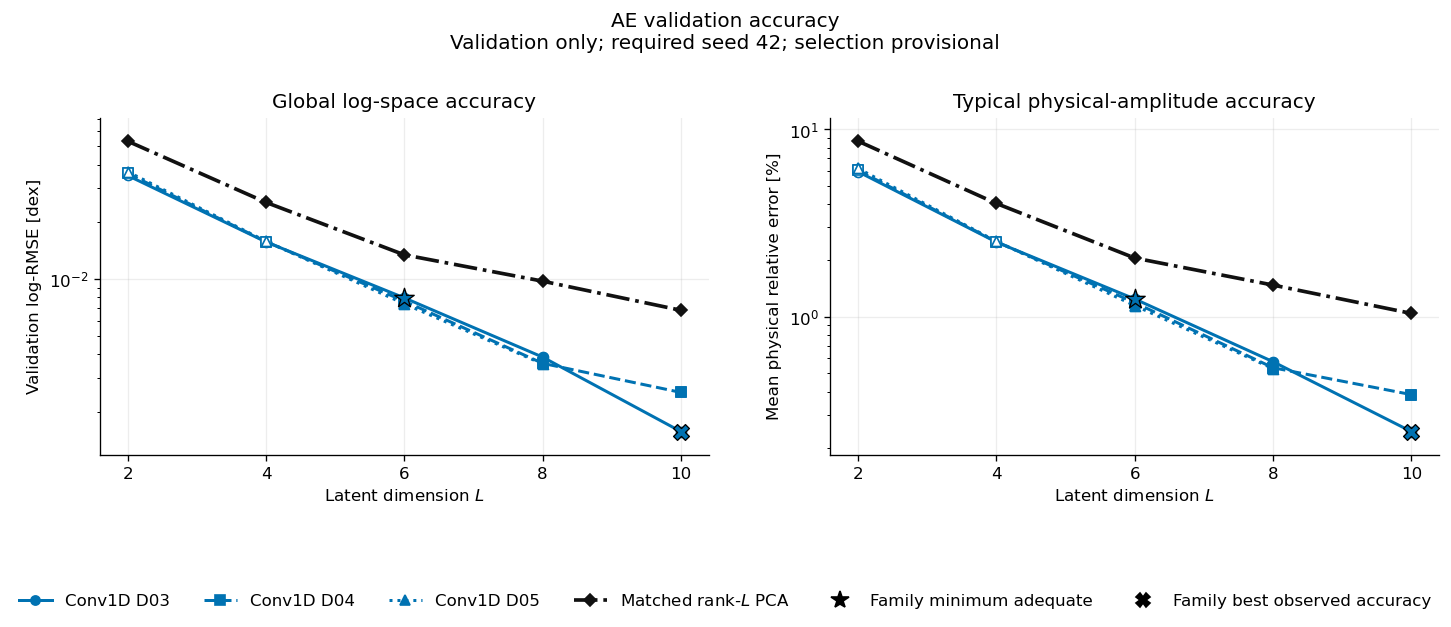

In [10]:
PCA_PLOT_ROWS = [
    {
        "cell_id": f"PCA:Rank{latent_dim:02d}",
        "architecture": "PCA",
        "depth": "PCA",
        "latent_dim": latent_dim,
        **{
            name: float(value)
            for name, value in pca_reference["ranks"][str(latent_dim)].items()
        },
    }
    for latent_dim in LATENT_DIMENSIONS
]

SHARED_METRIC_LIMITS = {}
for metric_name, presentation in METRIC_PRESENTATION.items():
    scale = float(presentation["scale"])
    pooled_values = [
        scale * float(record[metric_name])
        for record in ALL_RESULTS
    ]
    pooled_values.extend(
        scale * float(record[metric_name])
        for record in PCA_PLOT_ROWS
    )
    SHARED_METRIC_LIMITS[metric_name] = positive_log_limits(pooled_values)

AE_MINIMUM_CELL_IDS = {AE_SELECTION["minimum_adequate"]}
AE_ACCURACY_CELL_IDS = {AE_SELECTION["best_observed_accuracy"]}
VALIDATION_SUBTITLE = (
    "Validation only; required seed "
    + ", ".join(
        str(seed) for seed in SELECTION_POLICY["replicates"]["required_seeds"]
    )
    + "; selection provisional"
)


def plot_AE_validation_metric(
    axis,
    metric_name,
):
    """
    Plot one AE validation metric using the shared visual contract.
    
    Arguments:
        axis (matplotlib.axes.Axes):
            Destination axes.
        metric_name (str):
            Validation metric key in the shared presentation mapping.
    """
    presentation = METRIC_PRESENTATION[metric_name]
    plot_validation_metric_panel(
        axis,
        ELIGIBLE_RESULTS,
        PCA_PLOT_ROWS,
        LATENT_DIMENSIONS,
        metric_name,
        minimum_adequate_cell_ids=AE_MINIMUM_CELL_IDS,
        best_accuracy_cell_ids=AE_ACCURACY_CELL_IDS,
        scale=float(presentation["scale"]),
        ylabel=str(presentation["ylabel"]),
        y_limits=SHARED_METRIC_LIMITS[metric_name],
    )
    axis.set_title(str(presentation["title"]))


def finish_summary_figure(
    figure,
    axes,
    title,
    path,
):
    """
    Add the common legend, status subtitle, and margins to a summary figure.
    
    Arguments:
        figure (matplotlib.figure.Figure):
            Two-panel validation figure.
        axes (numpy.ndarray):
            Axes whose series share one legend.
        title (str):
            Figure-level scientific title.
        path (pathlib.Path):
            Destination PDF path.
    """
    handles, labels = axes[-1].get_legend_handles_labels()
    role_handles = selection_legend_handles()
    figure.legend(
        [*handles, *role_handles],
        [*labels, *(handle.get_label() for handle in role_handles)],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=6,
        frameon=False,
    )
    figure.suptitle(f"{title}\n{VALIDATION_SUBTITLE}", y=0.99)
    figure.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.28,
        top=0.82,
        wspace=0.20,
    )
    save_and_show(figure, path)


accuracy_path = FIGURE_DIRECTORY / "AE_Validation_Accuracy.pdf"
figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES["summary"])
plot_AE_validation_metric(axes[0], "log10_rmse")
plot_AE_validation_metric(axes[1], "mean_relative_error")
finish_summary_figure(
    figure,
    axes,
    "AE validation accuracy",
    accuracy_path,
)


Saved: Figure/NLA/AE/AE_Validation_Tails.pdf


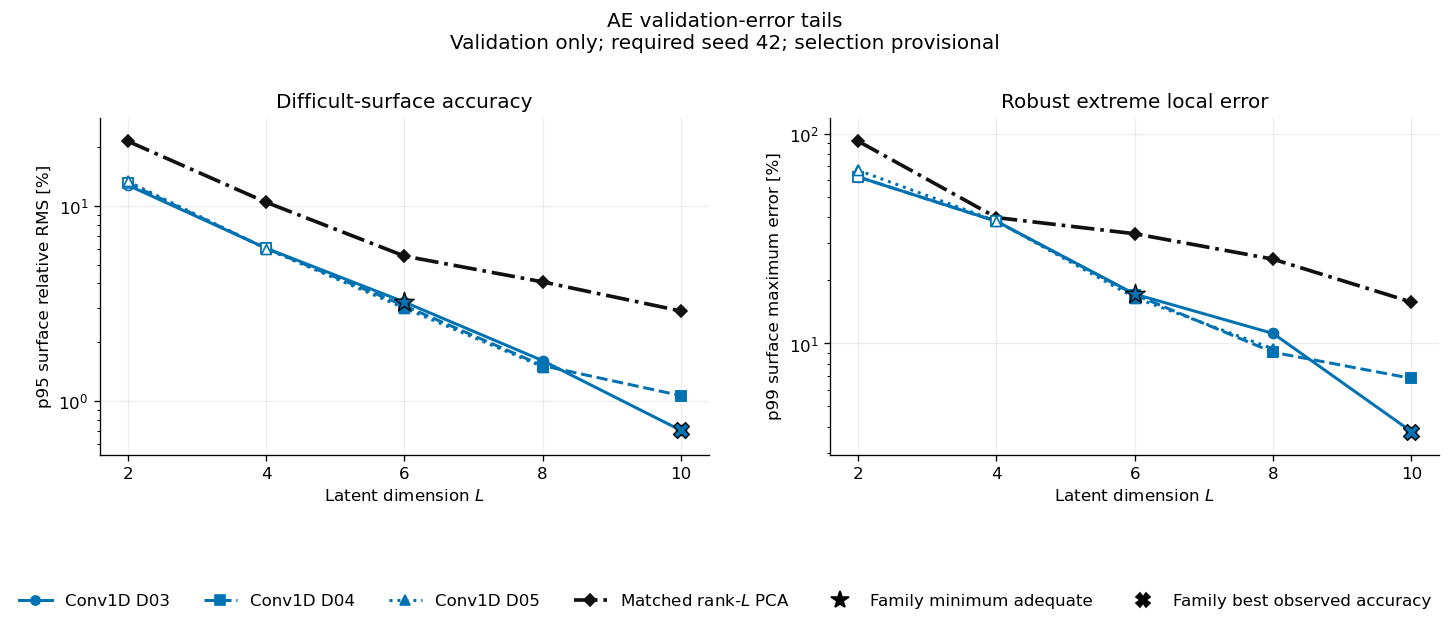

In [11]:
tail_path = FIGURE_DIRECTORY / "AE_Validation_Tails.pdf"
figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES["summary"])
plot_AE_validation_metric(axes[0], "surface_relative_rmse_p95")
plot_AE_validation_metric(axes[1], "surface_relative_maximum_p99")
finish_summary_figure(
    figure,
    axes,
    "AE validation-error tails",
    tail_path,
)


## Snapshot-selected diagnostics

Every detailed figure uses the AE family's authenticated minimum-adequate representative. Accuracy and tail summaries retain the full eligible grid and separately mark the best-observed-accuracy configuration. The selected-run figures use the same panels, units, scale definitions, and role semantics as the PCA-AE notebook.

Training histories and diagnostic arrays are read from stored artifacts. No inference is rerun. Cross-family colour limits are calculated only from the two independently selected diagnostic representatives declared by the live manifest.


Saved: Figure/NLA/AE/AE_Selected_Training_History.pdf


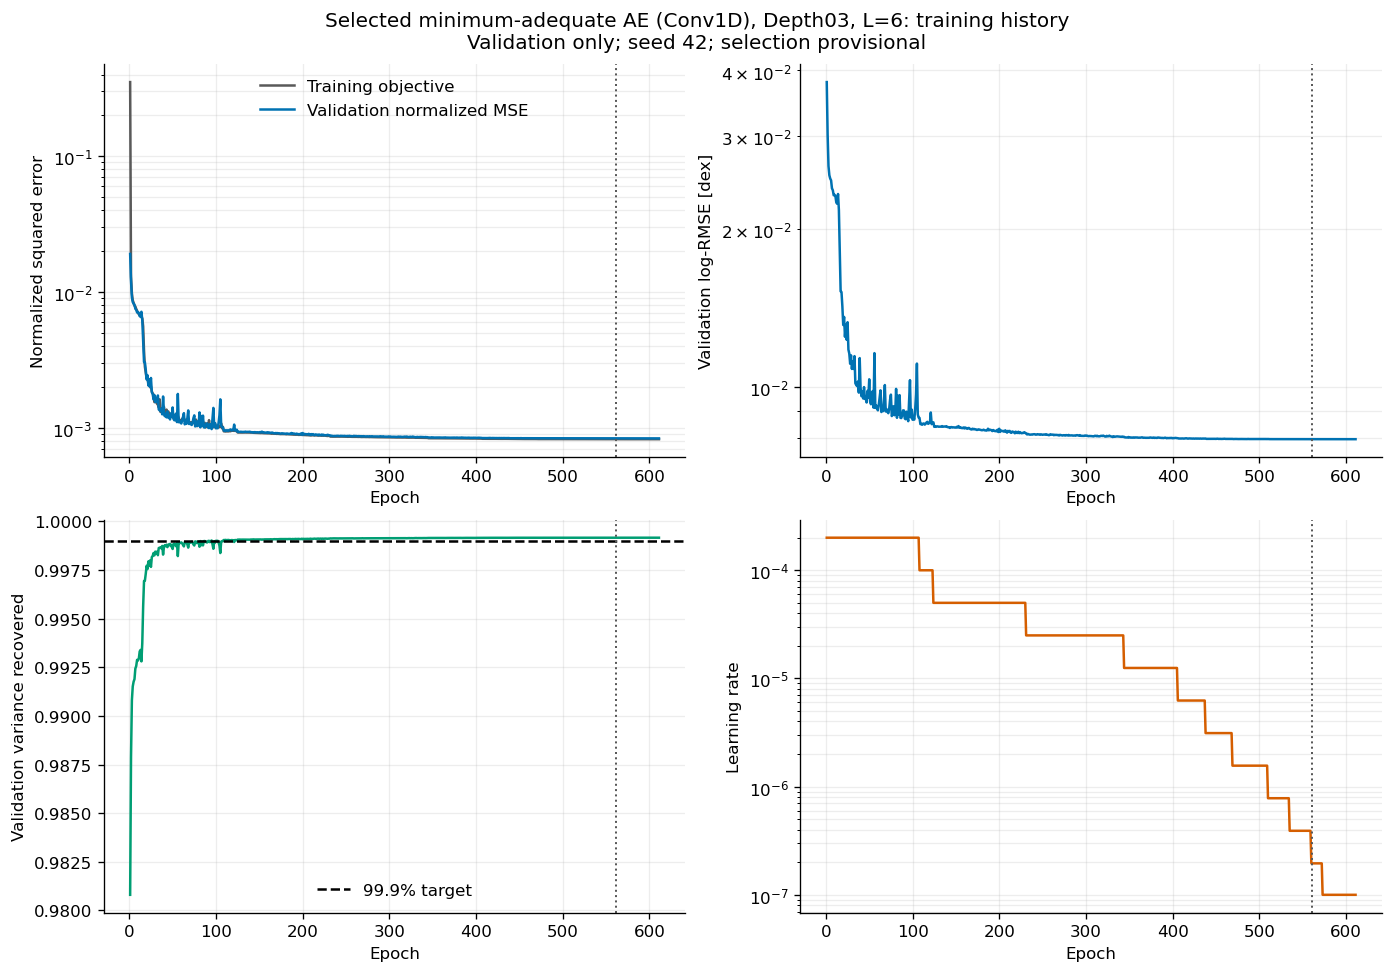

Best epoch 561 of 611; stopped early: True.


In [12]:
history = SELECTED_HISTORY
summary = SELECTED_SUMMARY

epochs = np.asarray([row["epoch"] for row in history])
train_loss = np.asarray([row["train_loss"] for row in history])
validation_loss = np.asarray(
    [row["validation"]["normalized_mse"] for row in history]
)
validation_log_rmse = np.asarray(
    [row["validation"]["log10_rmse"] for row in history]
)
validation_variance = np.asarray(
    [row["validation"]["variance_recovered"] for row in history]
)
learning_rate = np.asarray([row["learning_rate"] for row in history])
selected_family_color = FAMILY_COLORS[SELECTED_RECORD["architecture"]]


def selected_figure_title(
    diagnostic,
):
    """
    Format the common selected-model title and validation-only subtitle.
    
    Arguments:
        diagnostic (str):
            Scientific content described by the figure.
    
    Returns:
        title (str):
            Two-line selected-model figure title.
    """
    return (
        "Selected minimum-adequate AE "
        f"({SELECTED_RECORD['architecture']}), {SELECTED_RECORD['depth']}, "
        f"L={SELECTED_RECORD['latent_dim']}: {diagnostic}\n"
        f"Validation only; seed {AE_DIAGNOSTIC_RUN['seed']}; "
        "selection provisional"
    )


history_path = FIGURE_DIRECTORY / "AE_Selected_Training_History.pdf"
figure, axes = plt.subplots(
    2,
    2,
    figsize=FIGURE_SIZES["selected_training"],
    constrained_layout=True,
)
axes[0, 0].semilogy(
    epochs,
    train_loss,
    color="0.35",
    label="Training objective",
)
axes[0, 0].semilogy(
    epochs,
    validation_loss,
    color=selected_family_color,
    label="Validation normalized MSE",
)
axes[0, 0].set(xlabel="Epoch", ylabel="Normalized squared error")
axes[0, 0].legend(frameon=False)
axes[0, 1].semilogy(
    epochs,
    validation_log_rmse,
    color=selected_family_color,
)
axes[0, 1].set(
    xlabel="Epoch",
    ylabel="Validation log-RMSE [dex]",
)
axes[1, 0].plot(epochs, validation_variance, color="#009E73")
axes[1, 0].axhline(
    TARGET_VARIANCE_RECOVERED,
    color="black",
    linestyle="--",
    label="99.9% target",
)
axes[1, 0].set(
    xlabel="Epoch",
    ylabel="Validation variance recovered",
)
axes[1, 0].legend(frameon=False)
axes[1, 1].semilogy(epochs, learning_rate, color="#D55E00")
axes[1, 1].set(xlabel="Epoch", ylabel="Learning rate")
for axis in axes.flat:
    axis.axvline(
        summary["best_epoch"],
        color="0.35",
        linestyle=":",
        linewidth=1.2,
    )
    axis.grid(True, which="both", alpha=0.22)
figure.suptitle(selected_figure_title("training history"))
save_and_show(figure, history_path)
print(
    f"Best epoch {summary['best_epoch']} of {summary['epochs_completed']}; "
    f"stopped early: {summary['stopped_early']}."
)


Saved: Figure/NLA/AE/AE_Selected_Validation_Diagnostics.pdf


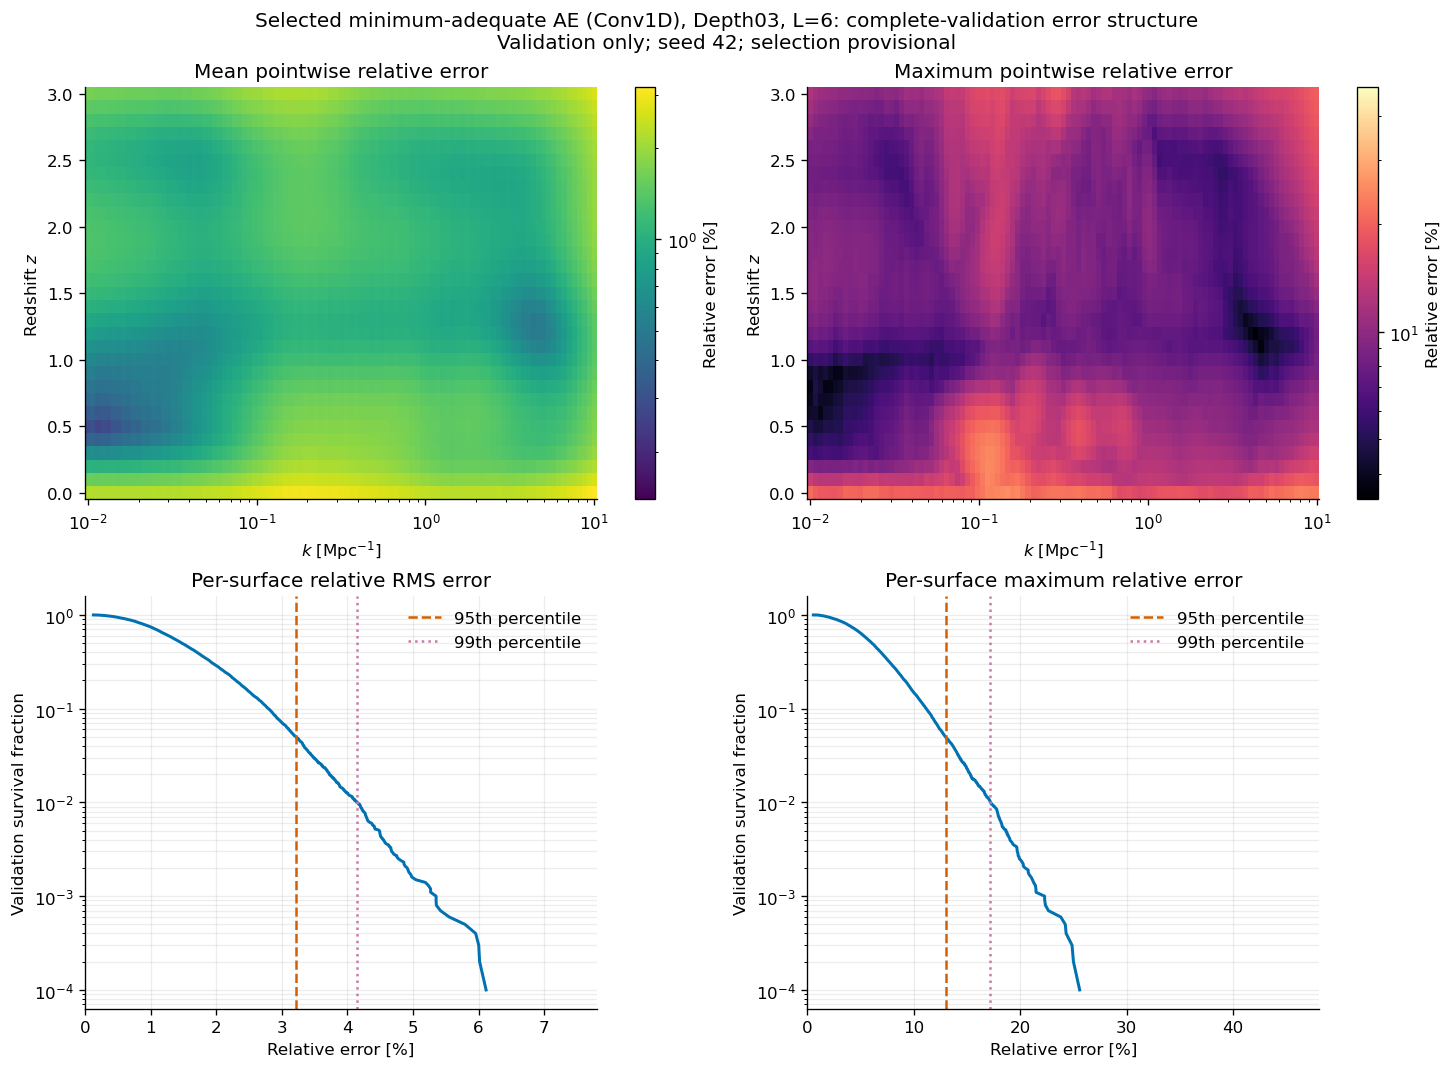

In [13]:
EXPECTED_DIAGNOSTIC_KEYS = {
    "mean_relative_error_map",
    "maximum_relative_error_map",
    "surface_relative_rmse",
    "surface_relative_maximum",
    "worst_split_positions",
    "worst_source_indices",
    "worst_target_log10",
    "worst_prediction_log10",
}
EXPECTED_DIAGNOSTIC_SHAPES = {
    "mean_relative_error_map": (31, 101),
    "maximum_relative_error_map": (31, 101),
    "surface_relative_rmse": (EXPECTED_VALIDATION_SAMPLES,),
    "surface_relative_maximum": (EXPECTED_VALIDATION_SAMPLES,),
    "worst_split_positions": (12,),
    "worst_source_indices": (12,),
    "worst_target_log10": (12, 31, 101),
    "worst_prediction_log10": (12, 31, 101),
}


def load_complete_validation_diagnostics(
    run_directory,
    expected_metrics=None,
):
    """
    Load and validate one complete-validation diagnostic artifact pair.
    
    Arguments:
        run_directory (pathlib.Path):
            Authenticated compressor run directory.
        expected_metrics (dict or None):
            Validation metrics to cross-check, when available.
    
    Returns:
        diagnostics (dict):
            Stored diagnostic summary and finite arrays.
    """
    run_directory = Path(run_directory)
    diagnostic_summary = read_json(
        run_directory / "ValidationDiagnostics.json"
    )
    if diagnostic_summary["complete_validation_split"] is not True:
        raise ValueError(f"Incomplete diagnostics: {run_directory}")
    if int(diagnostic_summary["number_of_surfaces"]) != EXPECTED_VALIDATION_SAMPLES:
        raise ValueError(f"Wrong diagnostic sample count: {run_directory}")
    with np.load(
        run_directory / "ValidationDiagnostics.npz",
        allow_pickle=False,
    ) as stored:
        if set(stored.files) != EXPECTED_DIAGNOSTIC_KEYS:
            raise ValueError(f"Unexpected diagnostics: {run_directory}")
        arrays = {name: np.asarray(stored[name]) for name in stored.files}
    for name, expected_shape in EXPECTED_DIAGNOSTIC_SHAPES.items():
        if arrays[name].shape != expected_shape:
            raise ValueError(f"Invalid {name} shape in {run_directory}.")
        if not np.all(np.isfinite(arrays[name])):
            raise ValueError(f"Non-finite {name} values in {run_directory}.")
    if expected_metrics is not None:
        for name in (
            "surface_relative_rmse_p95",
            "surface_relative_rmse_p99",
            "surface_relative_maximum_p95",
            "surface_relative_maximum_p99",
            "maximum_relative_error",
        ):
            if name not in expected_metrics:
                continue
            if not np.isclose(
                diagnostic_summary[name],
                expected_metrics[name],
                rtol=2.0e-6,
                atol=1.0e-8,
            ):
                raise ValueError(
                    f"Diagnostic/metric mismatch in {run_directory}: {name}"
                )
    return {"summary": diagnostic_summary, "arrays": arrays}


def load_representative_diagnostics(
    record,
):
    """
    Load diagnostics for one authenticated representative result row.
    
    Arguments:
        record (dict):
            Typed aggregate validation result.
    
    Returns:
        diagnostics (dict):
            Complete-validation diagnostic summary and arrays.
    """
    run_directory = resolve_project_path(
        record["representative_run_directory"],
        f"representative run for {record['cell_id']}",
    )
    live_matches = [
        audit
        for audit in LIVE_AUDIT_RECORDS
        if (
            audit["cell_id"] == record["cell_id"]
            and audit.get("run_directory")
            == record["representative_run_directory"]
            and audit["eligible_for_comparison"]
            and audit["diagnostics_ready"]
        )
    ]
    if len(live_matches) != 1:
        fail_selection(
            f"Representative diagnostics are no longer eligible: {record['cell_id']}."
        )
    return load_complete_validation_diagnostics(
        run_directory,
        expected_metrics=record,
    )


SELECTED_DIAGNOSTICS = load_complete_validation_diagnostics(
    SELECTED_DIRECTORY,
    expected_metrics=SELECTED_METRICS,
)
diagnostic_json = SELECTED_DIAGNOSTICS["summary"]
diagnostic_arrays = SELECTED_DIAGNOSTICS["arrays"]

PCA_AE_DIAGNOSTIC_RUN = DIAGNOSTIC_RUNS["PCA_AE"]
for artifact_name in (
    "ValidationDiagnostics.json",
    "ValidationDiagnostics.npz",
):
    authenticate_diagnostic_artifact(
        PCA_AE_DIAGNOSTIC_RUN,
        artifact_name,
        "PCA_AE",
    )
PCA_AE_DIAGNOSTIC_DIRECTORY = resolve_project_path(
    PCA_AE_DIAGNOSTIC_RUN["run_directory"],
    "diagnostic_runs.PCA_AE.run_directory",
)
PCA_AE_DIAGNOSTICS = load_complete_validation_diagnostics(
    PCA_AE_DIAGNOSTIC_DIRECTORY,
)
pca_ae_diagnostic_arrays = PCA_AE_DIAGNOSTICS["arrays"]

with h5py.File(SOURCE_PATH, "r") as source:
    k_values = source["coordinates/k"][:]
    z_values = source["coordinates/z"][:]

mean_error_map = diagnostic_arrays["mean_relative_error_map"]
maximum_error_map = diagnostic_arrays["maximum_relative_error_map"]
surface_rms = diagnostic_arrays["surface_relative_rmse"]
surface_maximum = diagnostic_arrays["surface_relative_maximum"]

mean_percent = 100.0 * mean_error_map
maximum_percent = 100.0 * maximum_error_map
pca_ae_mean_percent = (
    100.0 * pca_ae_diagnostic_arrays["mean_relative_error_map"]
)
pca_ae_maximum_percent = (
    100.0 * pca_ae_diagnostic_arrays["maximum_relative_error_map"]
)
mean_norm = shared_positive_log_norm(
    (mean_percent, pca_ae_mean_percent),
)
maximum_norm = shared_positive_log_norm(
    (maximum_percent, pca_ae_maximum_percent),
)

diagnostic_path = FIGURE_DIRECTORY / "AE_Selected_Validation_Diagnostics.pdf"
figure, axes = plt.subplots(
    2,
    2,
    figsize=FIGURE_SIZES["selected_diagnostics"],
    constrained_layout=True,
)
mean_image = axes[0, 0].pcolormesh(
    k_values,
    z_values,
    mean_percent,
    shading="auto",
    cmap="viridis",
    norm=mean_norm,
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
)
maximum_image = axes[0, 1].pcolormesh(
    k_values,
    z_values,
    maximum_percent,
    shading="auto",
    cmap="magma",
    norm=maximum_norm,
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
)
for axis in axes[0]:
    axis.set(
        xscale="log",
        xlabel=r"$k$ [Mpc$^{-1}$]",
        ylabel=r"Redshift $z$",
    )
    axis.grid(False)
axes[0, 0].set_title("Mean pointwise relative error")
axes[0, 1].set_title("Maximum pointwise relative error")
figure.colorbar(mean_image, ax=axes[0, 0], label="Relative error [%]")
figure.colorbar(maximum_image, ax=axes[0, 1], label="Relative error [%]")

for axis, array_name, p95_name, p99_name, title in (
    (
        axes[1, 0],
        "surface_relative_rmse",
        "surface_relative_rmse_p95",
        "surface_relative_rmse_p99",
        "Per-surface relative RMS error",
    ),
    (
        axes[1, 1],
        "surface_relative_maximum",
        "surface_relative_maximum_p95",
        "surface_relative_maximum_p99",
        "Per-surface maximum relative error",
    ),
):
    ordered, survival = empirical_survival(diagnostic_arrays[array_name])
    shared_upper = 100.0 * max(
        float(np.max(diagnostic_arrays[array_name])),
        float(np.max(pca_ae_diagnostic_arrays[array_name])),
    )
    axis.plot(
        100.0 * ordered,
        survival,
        color=selected_family_color,
        linewidth=1.8,
    )
    axis.axvline(
        100.0 * SELECTED_METRICS[p95_name],
        color="#D55E00",
        linestyle="--",
        label="95th percentile",
    )
    axis.axvline(
        100.0 * SELECTED_METRICS[p99_name],
        color="#CC79A7",
        linestyle=":",
        label="99th percentile",
    )
    axis.set(
        xlim=(0.0, shared_upper),
        yscale="log",
        xlabel="Relative error [%]",
        ylabel="Validation survival fraction",
        title=title,
    )
    axis.grid(True, which="both", alpha=0.22)
    axis.legend(frameon=False)

figure.suptitle(
    selected_figure_title("complete-validation error structure")
)
save_and_show(figure, diagnostic_path)


### Selected-bottleneck depth sensitivity

This supporting figure compares every eligible depth at the authenticated AE architecture and latent dimension. Missing depths remain explicit rather than being imputed. Mean and maximum error maps use normalizations pooled across the corresponding AE and PCA-AE depth sets, so the paired PDFs use the same colour meaning.


Saved: Figure/NLA/AE/AE_Selected_Depth_Sensitivity.pdf


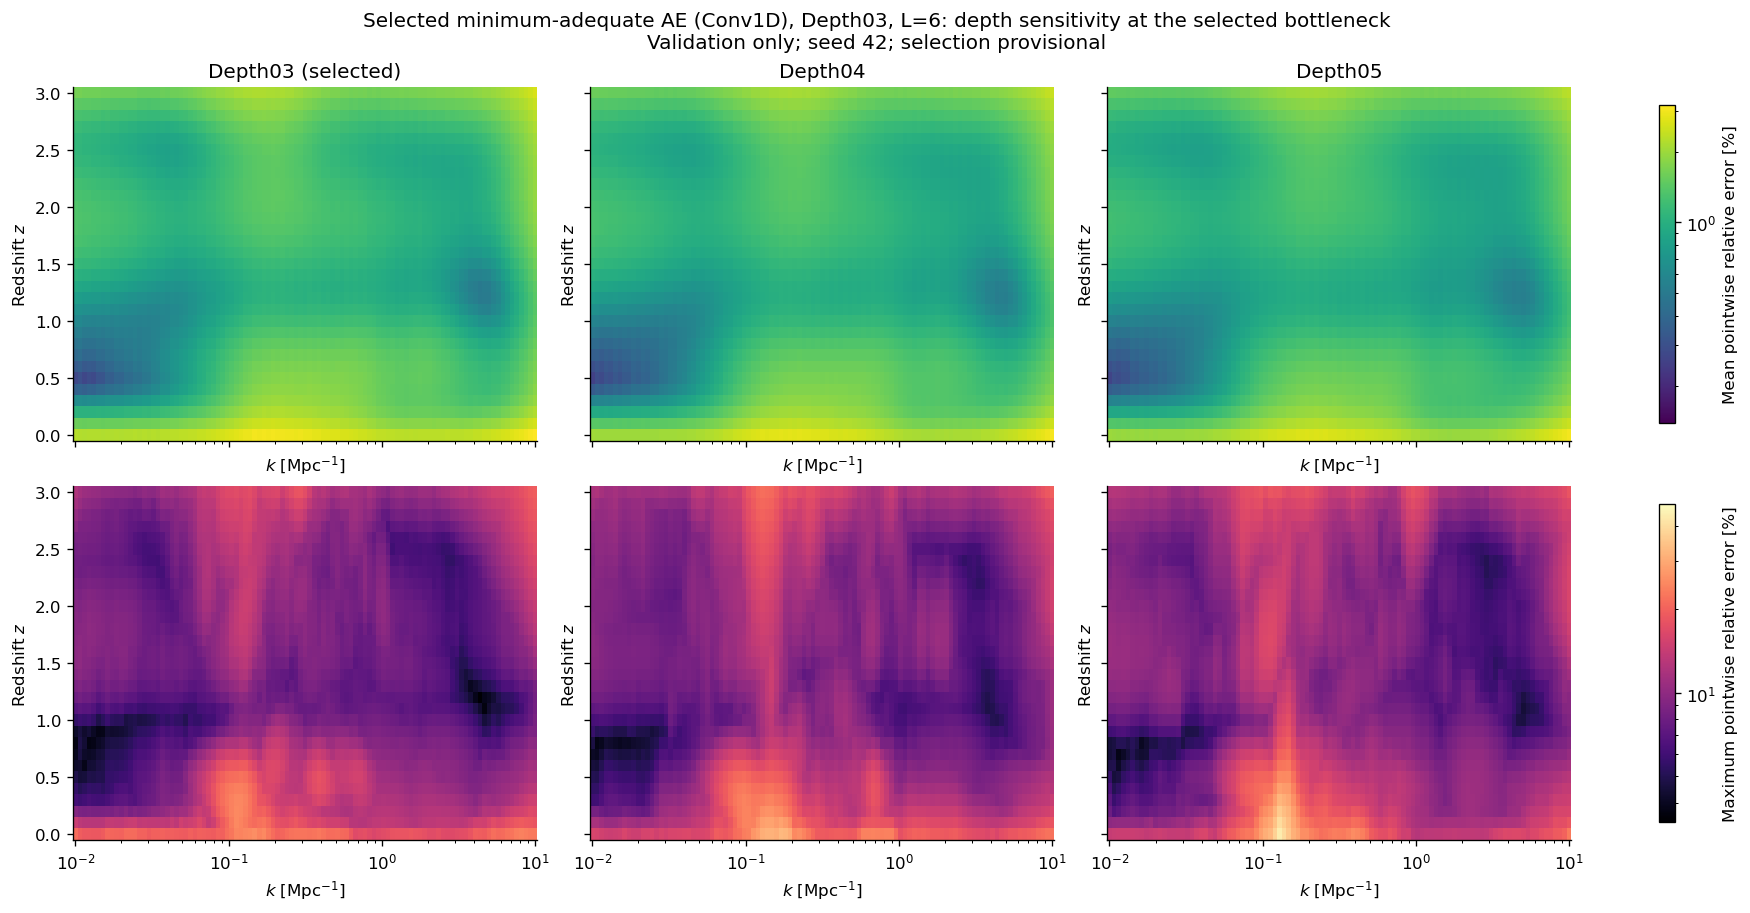

In [14]:
PCA_AE_SELECTION = SELECTIONS["by_family"]["PCA_AE"]
PCA_AE_SELECTED_RECORD = RESULT_BY_CELL_ID[
    PCA_AE_SELECTION["diagnostic_representative"]
]


def collect_depth_diagnostics(
    model_family,
    architecture,
    latent_dim,
):
    """
    Collect available representative diagnostics across configured depths.
    
    Arguments:
        model_family (str):
            Internal model-family name in the aggregate result table.
        architecture (str):
            Architecture whose depth sequence is requested.
        latent_dim (int):
            Selected latent dimension held fixed across depths.
    
    Returns:
        diagnostics (dict[str, dict]):
            Available complete-validation diagnostics keyed by depth.
    """
    diagnostics = {}
    for depth in DEPTHS:
        candidates = [
            record
            for record in ALL_RESULTS
            if (
                record["model_family"] == model_family
                and record["architecture"] == architecture
                and record["depth"] == depth
                and record["latent_dim"] == latent_dim
            )
        ]
        if len(candidates) > 1:
            fail_selection(
                f"Duplicate depth-sensitivity cells for {architecture} {depth}."
            )
        if candidates:
            diagnostics[depth] = load_representative_diagnostics(candidates[0])
    return diagnostics


AE_DEPTH_DIAGNOSTICS = collect_depth_diagnostics(
    SELECTED_RECORD["model_family"],
    SELECTED_RECORD["architecture"],
    SELECTED_RECORD["latent_dim"],
)
PCA_AE_DEPTH_DIAGNOSTICS = collect_depth_diagnostics(
    PCA_AE_SELECTED_RECORD["model_family"],
    PCA_AE_SELECTED_RECORD["architecture"],
    PCA_AE_SELECTED_RECORD["latent_dim"],
)
if SELECTED_RECORD["depth"] not in AE_DEPTH_DIAGNOSTICS:
    fail_selection("The selected AE depth is absent from depth sensitivity.")

depth_mean_arrays = [
    100.0 * diagnostics["arrays"]["mean_relative_error_map"]
    for diagnostics in (
        *AE_DEPTH_DIAGNOSTICS.values(),
        *PCA_AE_DEPTH_DIAGNOSTICS.values(),
    )
]
depth_maximum_arrays = [
    100.0 * diagnostics["arrays"]["maximum_relative_error_map"]
    for diagnostics in (
        *AE_DEPTH_DIAGNOSTICS.values(),
        *PCA_AE_DEPTH_DIAGNOSTICS.values(),
    )
]
depth_mean_norm = shared_positive_log_norm(depth_mean_arrays)
depth_maximum_norm = shared_positive_log_norm(depth_maximum_arrays)

depth_sensitivity_path = (
    FIGURE_DIRECTORY / "AE_Selected_Depth_Sensitivity.pdf"
)
figure, axes = plt.subplots(
    2,
    len(DEPTHS),
    figsize=FIGURE_SIZES["depth_sensitivity"],
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
mean_image = None
maximum_image = None
for column, depth in enumerate(DEPTHS):
    if depth not in AE_DEPTH_DIAGNOSTICS:
        for row in range(2):
            axes[row, column].set_axis_off()
            axes[row, column].text(
                0.5,
                0.5,
                f"{depth}\nunavailable",
                ha="center",
                va="center",
                transform=axes[row, column].transAxes,
            )
        continue
    arrays = AE_DEPTH_DIAGNOSTICS[depth]["arrays"]
    mean_image = axes[0, column].pcolormesh(
        k_values,
        z_values,
        100.0 * arrays["mean_relative_error_map"],
        shading="auto",
        cmap="viridis",
        norm=depth_mean_norm,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    maximum_image = axes[1, column].pcolormesh(
        k_values,
        z_values,
        100.0 * arrays["maximum_relative_error_map"],
        shading="auto",
        cmap="magma",
        norm=depth_maximum_norm,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    depth_title = depth
    if depth == SELECTED_RECORD["depth"]:
        depth_title += " (selected)"
    axes[0, column].set_title(depth_title)
    for row in range(2):
        axes[row, column].set_xscale("log")
        axes[row, column].set_xlabel(r"$k$ [Mpc$^{-1}$]")
        axes[row, column].grid(False)
    axes[0, column].set_ylabel(r"Redshift $z$")
    axes[1, column].set_ylabel(r"Redshift $z$")

if mean_image is None or maximum_image is None:
    raise RuntimeError("No AE depth-sensitivity maps are available.")
figure.colorbar(
    mean_image,
    ax=axes[0, :],
    label="Mean pointwise relative error [%]",
    shrink=0.9,
)
figure.colorbar(
    maximum_image,
    ax=axes[1, :],
    label="Maximum pointwise relative error [%]",
    shrink=0.9,
)
figure.suptitle(
    selected_figure_title("depth sensitivity at the selected bottleneck")
)
save_and_show(figure, depth_sensitivity_path)


Saved: Figure/NLA/AE/AE_Selected_Worst_Reconstructions.pdf


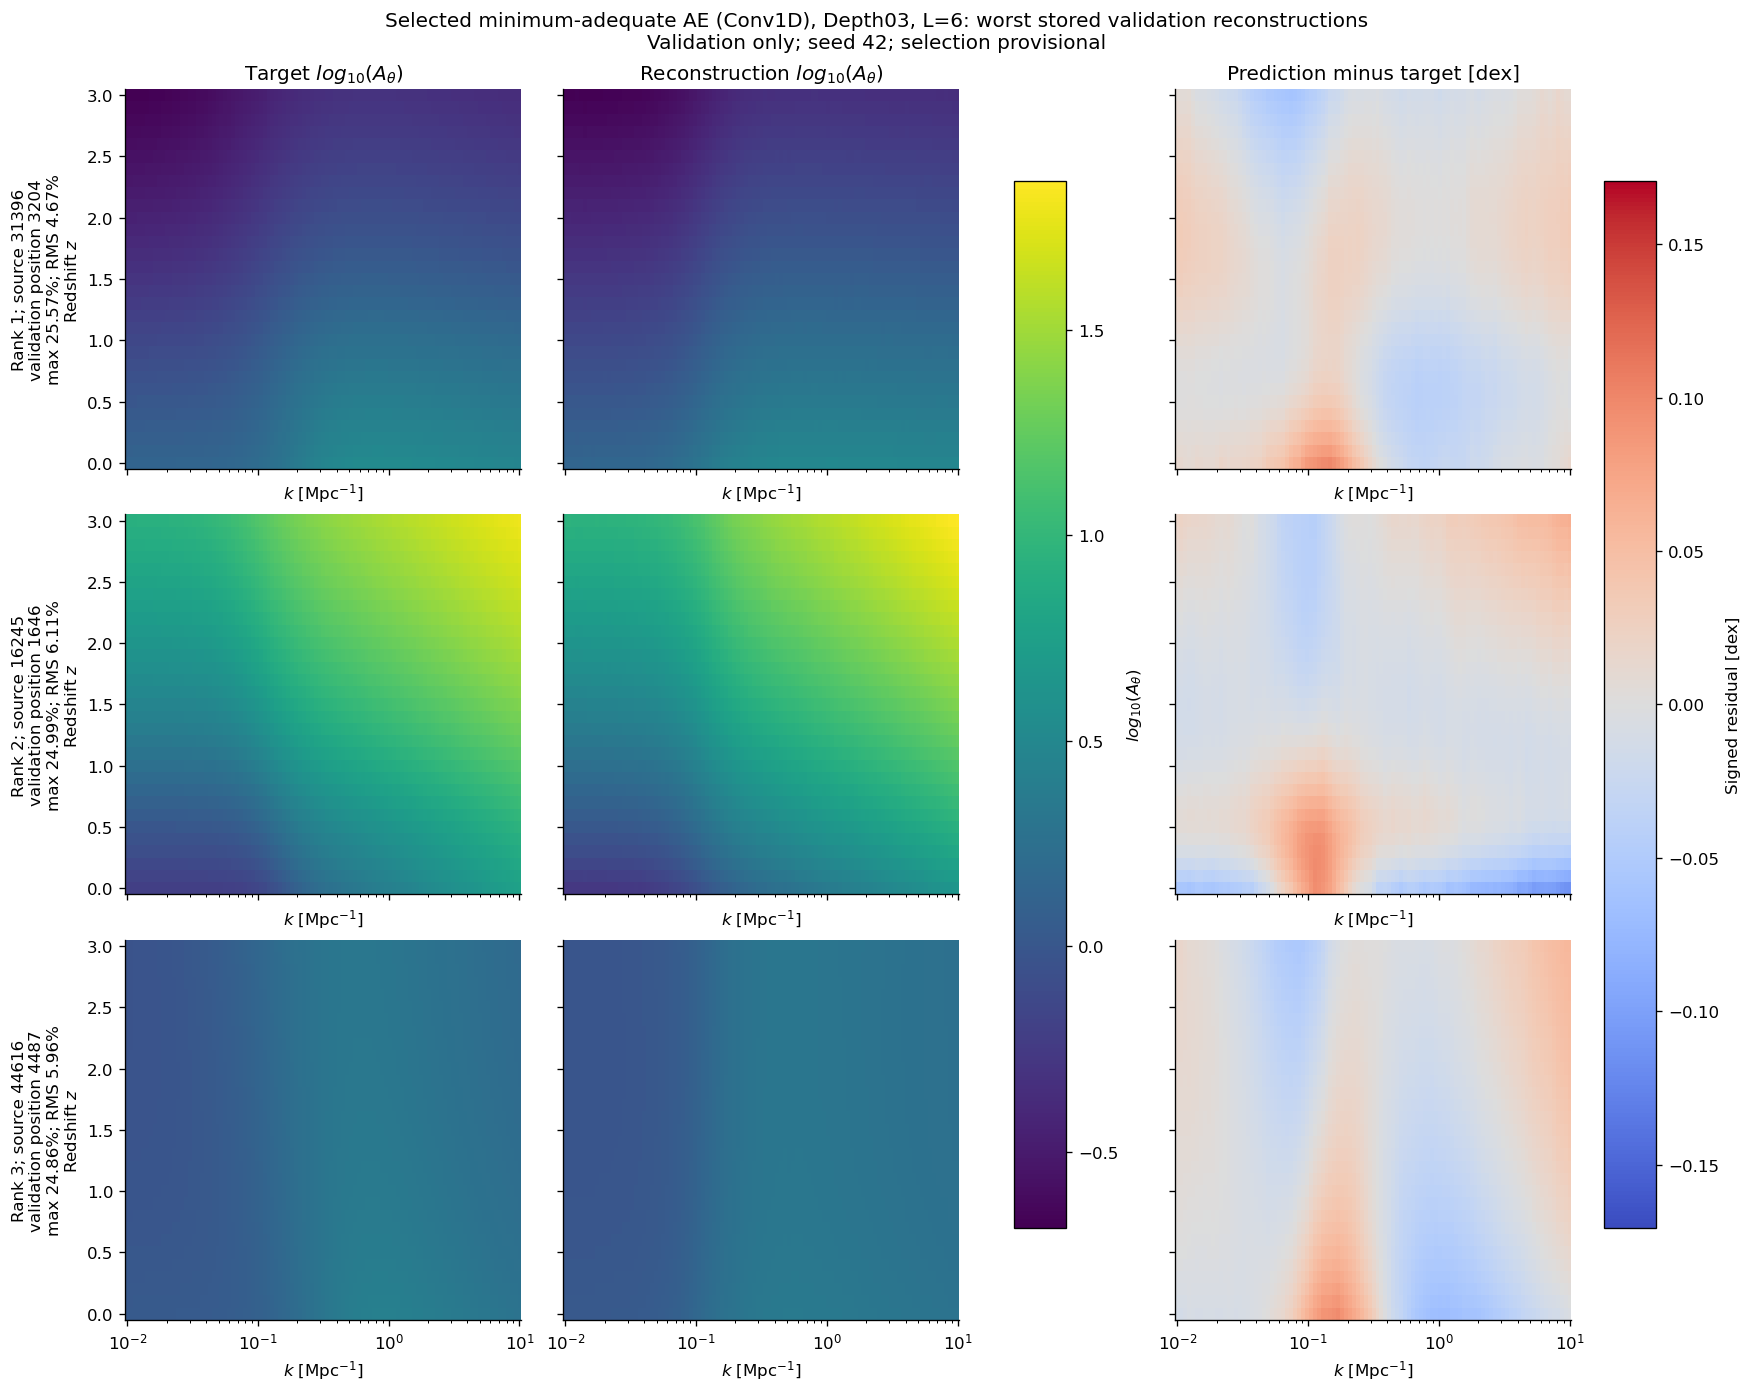

In [15]:
worst_positions = np.asarray(
    diagnostic_arrays["worst_split_positions"],
    dtype=int,
)
worst_errors = surface_maximum[worst_positions]
worst_order = np.argsort(worst_errors)[::-1][:3]
worst_targets = diagnostic_arrays["worst_target_log10"][worst_order]
worst_predictions = diagnostic_arrays["worst_prediction_log10"][worst_order]
worst_source_indices = diagnostic_arrays["worst_source_indices"][worst_order]
worst_positions = worst_positions[worst_order]
worst_errors = worst_errors[worst_order]
worst_rms_errors = surface_rms[worst_positions]
worst_residuals = worst_predictions - worst_targets

counterpart_positions = np.asarray(
    pca_ae_diagnostic_arrays["worst_split_positions"],
    dtype=int,
)
counterpart_errors = pca_ae_diagnostic_arrays[
    "surface_relative_maximum"
][counterpart_positions]
counterpart_order = np.argsort(counterpart_errors)[::-1][:3]
counterpart_targets = pca_ae_diagnostic_arrays[
    "worst_target_log10"
][counterpart_order]
counterpart_predictions = pca_ae_diagnostic_arrays[
    "worst_prediction_log10"
][counterpart_order]
counterpart_residuals = counterpart_predictions - counterpart_targets

amplitude_minimum = float(
    min(
        np.min(worst_targets),
        np.min(worst_predictions),
        np.min(counterpart_targets),
        np.min(counterpart_predictions),
    )
)
amplitude_maximum = float(
    max(
        np.max(worst_targets),
        np.max(worst_predictions),
        np.max(counterpart_targets),
        np.max(counterpart_predictions),
    )
)
residual_limit = max(
    float(np.max(np.abs(worst_residuals))),
    float(np.max(np.abs(counterpart_residuals))),
    np.finfo(np.float32).eps,
)

reconstruction_path = (
    FIGURE_DIRECTORY / "AE_Selected_Worst_Reconstructions.pdf"
)
figure, axes = plt.subplots(
    3,
    3,
    figsize=FIGURE_SIZES["worst_reconstructions"],
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for row in range(3):
    target_image = axes[row, 0].pcolormesh(
        k_values,
        z_values,
        worst_targets[row],
        shading="auto",
        cmap="viridis",
        vmin=amplitude_minimum,
        vmax=amplitude_maximum,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    axes[row, 1].pcolormesh(
        k_values,
        z_values,
        worst_predictions[row],
        shading="auto",
        cmap="viridis",
        vmin=amplitude_minimum,
        vmax=amplitude_maximum,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    residual_image = axes[row, 2].pcolormesh(
        k_values,
        z_values,
        worst_residuals[row],
        shading="auto",
        cmap="coolwarm",
        vmin=-residual_limit,
        vmax=residual_limit,
        linewidth=0.0,
        antialiased=False,
        rasterized=True,
    )
    axes[row, 0].set_ylabel(
        f"Rank {row + 1}; source {worst_source_indices[row]}\n"
        f"validation position {worst_positions[row]}\n"
        f"max {100.0 * worst_errors[row]:.2f}%; "
        f"RMS {100.0 * worst_rms_errors[row]:.2f}%\n"
        r"Redshift $z$"
    )
    for column in range(3):
        axes[row, column].set_xscale("log")
        axes[row, column].set_xlabel(r"$k$ [Mpc$^{-1}$]")
        axes[row, column].grid(False)

axes[0, 0].set_title(r"Target $log_{10}(A_\theta)$")
axes[0, 1].set_title(r"Reconstruction $log_{10}(A_\theta)$")
axes[0, 2].set_title("Prediction minus target [dex]")
figure.colorbar(
    target_image,
    ax=axes[:, :2],
    label=r"$log_{10}(A_\theta)$",
    shrink=0.85,
)
figure.colorbar(
    residual_image,
    ax=axes[:, 2],
    label="Signed residual [dex]",
    shrink=0.85,
)
figure.suptitle(
    selected_figure_title("worst stored validation reconstructions")
)
save_and_show(figure, reconstruction_path)


## Latent geometry and physical-parameter associations

The latent coordinates are not identifiable across model families, seeds, permutations, sign changes, rotations, or nonlinear reparameterizations. They must not be compared coordinate by coordinate and are never selection metrics.

For both AE and PCA-AE, the authenticated training latent export defines the centring and scale. The resulting transformation is applied unchanged to all 10,000 validation latents. The common 2×2 geometry figure diagnoses validation-error localization, training-to-validation shift, and latent redundancy. Undefined correlations and collapsed coordinates are masked rather than replaced by zero.


Saved: Figure/NLA/AE/AE_Selected_Latent_Geometry.pdf


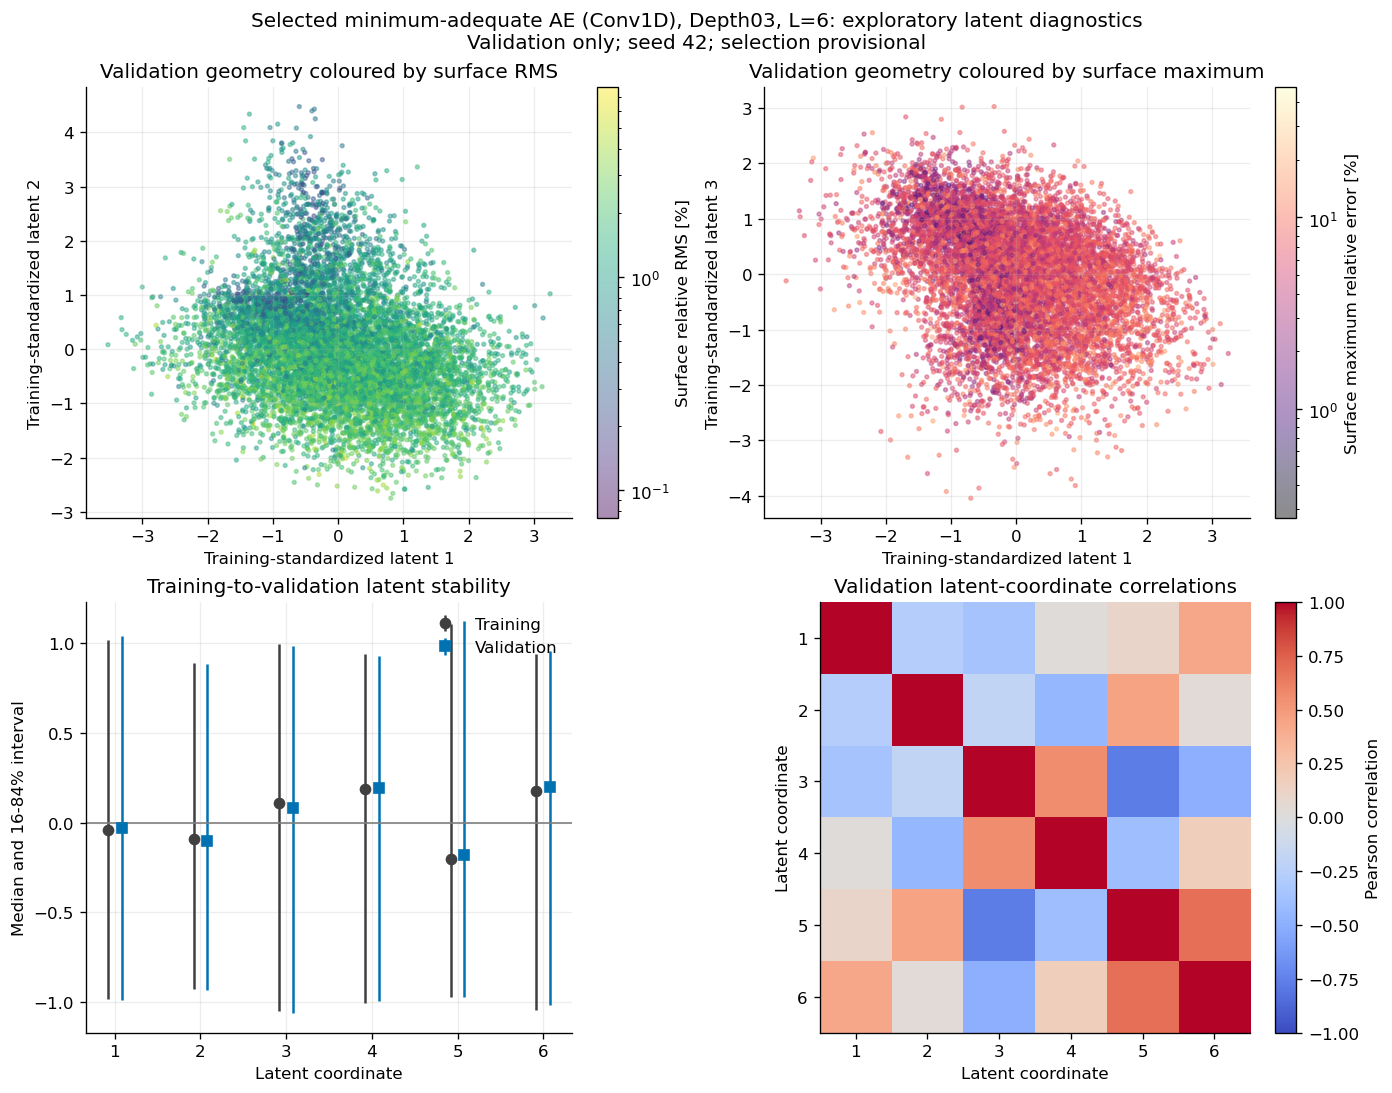

Collapsed latent coordinates: []


In [16]:
latent_path = SELECTED_DIRECTORY / "Latents.hdf5"
if not latent_path.is_file():
    raise FileNotFoundError(
        "The declared drill-down requires an existing train/validation latent export."
    )

with h5py.File(latent_path, "r") as latent_file:
    exported_splits = json.loads(latent_file.attrs["exported_splits"])
    assert exported_splits == ["train", "validation"]
    assert "test" not in latent_file["splits"]
    train_latent = latent_file["splits/train/latent"][:]
    validation_latent = latent_file["splits/validation/latent"][:]
    train_source_indices = latent_file["splits/train/source_indices"][:]
    validation_source_indices = latent_file[
        "splits/validation/source_indices"
    ][:]

with h5py.File(SOURCE_PATH, "r") as source:
    assert np.array_equal(train_source_indices, source["splits/train"][:])
    assert np.array_equal(
        validation_source_indices,
        source["splits/validation"][:],
    )

latent_mean = np.mean(train_latent, axis=0, dtype=np.float64)
latent_standard_deviation = np.std(
    train_latent,
    axis=0,
    dtype=np.float64,
)
valid_latent_coordinates = (
    np.isfinite(latent_standard_deviation)
    & (latent_standard_deviation > 0.0)
)
collapsed_coordinates = np.flatnonzero(~valid_latent_coordinates)
train_standardized = np.full_like(train_latent, np.nan, dtype=float)
validation_standardized = np.full_like(validation_latent, np.nan, dtype=float)
train_standardized[:, valid_latent_coordinates] = (
    train_latent[:, valid_latent_coordinates]
    - latent_mean[valid_latent_coordinates]
) / latent_standard_deviation[valid_latent_coordinates]
validation_standardized[:, valid_latent_coordinates] = (
    validation_latent[:, valid_latent_coordinates]
    - latent_mean[valid_latent_coordinates]
) / latent_standard_deviation[valid_latent_coordinates]

valid_coordinate_indices = np.flatnonzero(valid_latent_coordinates)
if len(valid_coordinate_indices) < 2:
    raise ValueError(
        "At least two non-collapsed latent coordinates are required for geometry."
    )
first_coordinate = int(valid_coordinate_indices[0])
second_coordinate = int(valid_coordinate_indices[1])
third_coordinate = int(
    valid_coordinate_indices[2]
    if len(valid_coordinate_indices) >= 3
    else valid_coordinate_indices[1]
)

geometry_path = FIGURE_DIRECTORY / "AE_Selected_Latent_Geometry.pdf"
figure, axes = plt.subplots(
    2,
    2,
    figsize=FIGURE_SIZES["latent_geometry"],
    constrained_layout=True,
)
rms_percent = 100.0 * surface_rms
maximum_percent = 100.0 * surface_maximum
rms_norm = shared_positive_log_norm(
    (
        rms_percent,
        100.0 * pca_ae_diagnostic_arrays["surface_relative_rmse"],
    )
)
surface_maximum_norm = shared_positive_log_norm(
    (
        maximum_percent,
        100.0 * pca_ae_diagnostic_arrays["surface_relative_maximum"],
    )
)
rms_scatter = axes[0, 0].scatter(
    validation_standardized[:, first_coordinate],
    validation_standardized[:, second_coordinate],
    c=rms_percent,
    s=5,
    alpha=0.45,
    cmap="viridis",
    norm=rms_norm,
    rasterized=True,
)
maximum_scatter = axes[0, 1].scatter(
    validation_standardized[:, first_coordinate],
    validation_standardized[:, third_coordinate],
    c=maximum_percent,
    s=5,
    alpha=0.45,
    cmap="magma",
    norm=surface_maximum_norm,
    rasterized=True,
)
axes[0, 0].set(
    xlabel=f"Training-standardized latent {first_coordinate + 1}",
    ylabel=f"Training-standardized latent {second_coordinate + 1}",
    title="Validation geometry coloured by surface RMS",
)
axes[0, 1].set(
    xlabel=f"Training-standardized latent {first_coordinate + 1}",
    ylabel=f"Training-standardized latent {third_coordinate + 1}",
    title="Validation geometry coloured by surface maximum",
)
figure.colorbar(
    rms_scatter,
    ax=axes[0, 0],
    label="Surface relative RMS [%]",
)
figure.colorbar(
    maximum_scatter,
    ax=axes[0, 1],
    label="Surface maximum relative error [%]",
)

latent_dimension = validation_standardized.shape[1]
coordinate_numbers = np.arange(1, latent_dimension + 1)
train_quantiles = np.full((3, latent_dimension), np.nan)
validation_quantiles = np.full((3, latent_dimension), np.nan)
train_quantiles[:, valid_latent_coordinates] = np.quantile(
    train_standardized[:, valid_latent_coordinates],
    (0.16, 0.50, 0.84),
    axis=0,
)
validation_quantiles[:, valid_latent_coordinates] = np.quantile(
    validation_standardized[:, valid_latent_coordinates],
    (0.16, 0.50, 0.84),
    axis=0,
)
axes[1, 0].errorbar(
    coordinate_numbers - 0.08,
    train_quantiles[1],
    yerr=np.vstack(
        (
            train_quantiles[1] - train_quantiles[0],
            train_quantiles[2] - train_quantiles[1],
        )
    ),
    fmt="o",
    color="0.25",
    label="Training",
)
axes[1, 0].errorbar(
    coordinate_numbers + 0.08,
    validation_quantiles[1],
    yerr=np.vstack(
        (
            validation_quantiles[1] - validation_quantiles[0],
            validation_quantiles[2] - validation_quantiles[1],
        )
    ),
    fmt="s",
    color=selected_family_color,
    label="Validation",
)
axes[1, 0].axhline(0.0, color="0.5", linewidth=1.0)
axes[1, 0].set(
    xlabel="Latent coordinate",
    ylabel="Median and 16-84% interval",
    title="Training-to-validation latent stability",
    xticks=coordinate_numbers,
)
axes[1, 0].legend(frameon=False)

latent_correlations = np.full((latent_dimension, latent_dimension), np.nan)
valid_correlations = np.corrcoef(
    validation_standardized[:, valid_latent_coordinates],
    rowvar=False,
)
latent_correlations[np.ix_(valid_latent_coordinates, valid_latent_coordinates)] = (
    valid_correlations
)
latent_cmap = plt.get_cmap("coolwarm").copy()
latent_cmap.set_bad("lightgrey")
latent_image = axes[1, 1].imshow(
    np.ma.masked_invalid(latent_correlations),
    vmin=-1.0,
    vmax=1.0,
    cmap=latent_cmap,
    aspect="equal",
)
axes[1, 1].set(
    xlabel="Latent coordinate",
    ylabel="Latent coordinate",
    title="Validation latent-coordinate correlations",
    xticks=np.arange(latent_dimension),
    yticks=np.arange(latent_dimension),
    xticklabels=coordinate_numbers,
    yticklabels=coordinate_numbers,
)
axes[1, 1].grid(False)
figure.colorbar(latent_image, ax=axes[1, 1], label="Pearson correlation")
figure.suptitle(selected_figure_title("exploratory latent diagnostics"))
save_and_show(figure, geometry_path)

print("Collapsed latent coordinates:", collapsed_coordinates.tolist())


Saved: Figure/NLA/AE/AE_Selected_Latent_Parameter_Correlations.pdf


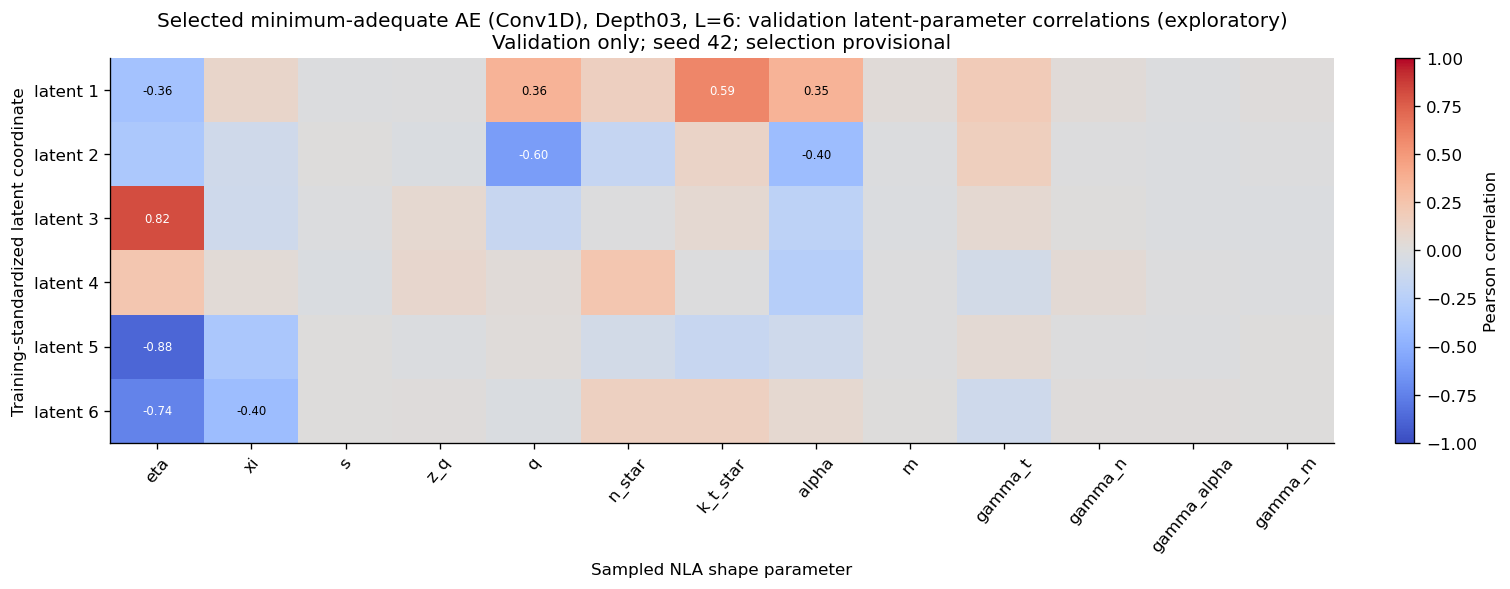

All validation latent-parameter correlations are defined.


In [17]:
def read_hdf5_rows(
    dataset,
    indices,
):
    """
    Read arbitrary unique HDF5 rows in the requested output order.
    
    Arguments:
        dataset (h5py.Dataset):
            Row-major source dataset.
        indices (numpy.ndarray):
            Unique source-row indices in requested output order.
    
    Returns:
        values (numpy.ndarray):
            Requested rows in the original index order.
    """
    indices = np.asarray(indices, dtype=np.int64)
    order = np.argsort(indices)
    sorted_indices = indices[order]
    if len(np.unique(sorted_indices)) != len(sorted_indices):
        raise ValueError("Source indices must be unique.")
    sorted_values = dataset[sorted_indices]
    values = np.empty_like(sorted_values)
    values[order] = sorted_values
    return values


with h5py.File(SOURCE_PATH, "r") as source:
    authoritative_validation_indices = source["splits/validation"][:]
    if not np.array_equal(
        validation_source_indices,
        authoritative_validation_indices,
    ):
        raise ValueError("Latent/source validation indices are misaligned.")
    parameter_values = read_hdf5_rows(
        source["parameters/values"],
        validation_source_indices,
    )
    parameter_names = [
        value.decode() if isinstance(value, bytes) else str(value)
        for value in source["parameters/names"][:]
    ]

parameter_correlations = np.empty((latent_dimension, len(parameter_names)))
undefined_correlations = []
for latent_index in range(latent_dimension):
    for parameter_index, parameter_name in enumerate(parameter_names):
        value = safe_pearson_correlation(
            validation_standardized[:, latent_index],
            parameter_values[:, parameter_index],
        )
        parameter_correlations[latent_index, parameter_index] = value
        if not np.isfinite(value):
            undefined_correlations.append(
                (f"latent {latent_index + 1}", parameter_name)
            )

correlation_cmap = plt.get_cmap("coolwarm").copy()
correlation_cmap.set_bad("lightgrey")
correlation_path = (
    FIGURE_DIRECTORY / "AE_Selected_Latent_Parameter_Correlations.pdf"
)
figure, axis = plt.subplots(
    figsize=FIGURE_SIZES["latent_parameter_correlations"],
    constrained_layout=True,
)
correlation_image = axis.imshow(
    np.ma.masked_invalid(parameter_correlations),
    aspect="auto",
    cmap=correlation_cmap,
    vmin=-1.0,
    vmax=1.0,
)
axis.set(
    xlabel="Sampled NLA shape parameter",
    ylabel="Training-standardized latent coordinate",
    title=selected_figure_title(
        "validation latent-parameter correlations (exploratory)"
    ),
    xticks=np.arange(len(parameter_names)),
    yticks=np.arange(latent_dimension),
    xticklabels=parameter_names,
    yticklabels=[
        f"latent {index + 1}" for index in range(latent_dimension)
    ],
)
axis.tick_params(axis="x", rotation=50)
axis.grid(False)
for row in range(latent_dimension):
    for column in range(len(parameter_names)):
        value = parameter_correlations[row, column]
        if np.isfinite(value) and abs(value) >= 0.35:
            axis.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if abs(value) >= 0.55 else "black",
                fontsize=7,
            )
figure.colorbar(
    correlation_image,
    ax=axis,
    label="Pearson correlation",
)
save_and_show(figure, correlation_path)

if undefined_correlations:
    print("Undefined constant-input correlations:")
    for latent_name, parameter_name in undefined_correlations:
        print(f"  {latent_name} versus {parameter_name}")
else:
    print("All validation latent-parameter correlations are defined.")


## Artifact-derived findings and consistency checks

The following summary is generated from eligible current validation records. Its wording remains conditional on completed coverage and the single required seed. The shared figures retain unavailable configurations as genuine gaps, and the latent diagnostics remain exploratory rather than selection evidence.


In [18]:
finding_lines = [
    "### Current AE validation findings",
    "",
    (
        f"- **Coverage:** {len(ELIGIBLE_RESULTS)} of "
        f"{len(ARCHITECTURES) * len(DEPTHS) * len(LATENT_DIMENSIONS)} "
        "configured cells currently have eligible complete-validation results."
    ),
]

for architecture in ARCHITECTURES:
    for depth in DEPTHS:
        dimensions = [
            latent_dim
            for latent_dim in LATENT_DIMENSIONS
            if (architecture, depth, latent_dim) in RESULT_BY_KEY
        ]
        if not dimensions:
            continue
        first_qualified = next(
            (
                latent_dim
                for latent_dim in dimensions
                if RESULT_BY_KEY[(architecture, depth, latent_dim)][
                    "variance_recovered"
                ]
                >= TARGET_VARIANCE_RECOVERED
            ),
            None,
        )
        finding_lines.append(
            f"- **{architecture} {depth}:** completed L={dimensions}; "
            + (
                f"first sampled 99.9% variance-recovery point is L={first_qualified}."
                if first_qualified is not None
                else "the sampled completed points do not yet reach 99.9%."
            )
        )

improvement_count = sum(
    bool(record["autoencoder_outperforms_pca"])
    for record in ELIGIBLE_RESULTS
)
finding_lines.append(
    f"- **Matched PCA:** {improvement_count}/{len(ELIGIBLE_RESULTS)} eligible "
    "current points improve both variance recovery and log-space MSE relative "
    "to PCA at the same latent dimension."
)

for latent_dim in LATENT_DIMENSIONS:
    candidates = [
        record
        for record in ELIGIBLE_RESULTS
        if record["latent_dim"] == latent_dim
    ]
    if not candidates:
        continue
    best = min(candidates, key=lambda record: record["log10_rmse"])
    finding_lines.append(
        f"- **Best observed AE at L={latent_dim}:** "
        f"{best['architecture']} {best['depth']} with log-space RMSE "
        f"{best['log10_rmse']:.5f} dex."
    )

finding_lines.extend(
    [
        f"- **Selection:** {format_configuration(RESULT_BY_CELL_ID[AE_SELECTION['minimum_adequate']])} "
        "is the minimum-adequate AE; "
        f"{format_configuration(RESULT_BY_CELL_ID[AE_SELECTION['best_observed_accuracy']])} "
        "is the separate best-observed-accuracy AE.",
        "- **Limit:** the current snapshot contains one seed per eligible cell "
        "with nondeterministic accelerator operations; no uncertainty band or "
        "robust depth optimum is claimed.",
        "- **Scope:** incomplete and legacy Conv2D runs are excluded, so these plots "
        "do not yet establish a current Conv1D-Conv2D comparison.",
    ]
)
display(Markdown("\n".join(finding_lines)))

for record in ELIGIBLE_RESULTS:
    eligible_audits = [
        audit
        for audit in AUDIT_RECORDS
        if (
            audit["cell_id"] == record["cell_id"]
            and parse_boolean(
                audit["eligible_for_comparison"],
                "eligible_for_comparison",
            )
        )
    ]
    assert eligible_audits
    assert record["n_runs"] == len(record["run_directories"])
    assert record["n_seeds"] == len(record["seeds"])
    assert record["diagnostics_ready"]
    assert record["autoencoder_outperforms_pca"]

assert SELECTED_AUDIT["current_configuration"]
assert SELECTED_AUDIT["status"] == "eligible"
assert SELECTED_AUDIT["eligible_for_comparison"]
assert SELECTED_SUMMARY["test_split_used_during_training"] is False
assert SELECTED_SUMMARY["training_samples"] == EXPECTED_TRAINING_SAMPLES
assert SELECTED_SUMMARY["validation_samples"] == EXPECTED_VALIDATION_SAMPLES
assert SELECTED_METRICS["number_of_surfaces"] == EXPECTED_VALIDATION_SAMPLES
assert SELECTED_RESOLVED_CONFIG["runtime"]["maximum_train_samples"] is None
assert (
    SELECTED_RESOLVED_CONFIG["runtime"]["maximum_validation_samples"]
    is None
)
selected_rank = str(SELECTED_RECORD["latent_dim"])
assert (
    SELECTED_VALIDATION_ARTIFACT["pca_comparison"]["pca_metrics"]
    == pca_reference["ranks"][selected_rank]
)

assert np.isclose(
    np.quantile(surface_rms, 0.95),
    SELECTED_METRICS["surface_relative_rmse_p95"],
    rtol=1.0e-6,
)
assert np.isclose(
    np.quantile(surface_maximum, 0.99),
    SELECTED_METRICS["surface_relative_maximum_p99"],
    rtol=1.0e-6,
)
assert len(validation_latent) == EXPECTED_VALIDATION_SAMPLES
assert len(train_latent) == EXPECTED_TRAINING_SAMPLES

EXPECTED_FIGURES = (
    accuracy_path,
    tail_path,
    history_path,
    diagnostic_path,
    depth_sensitivity_path,
    reconstruction_path,
    geometry_path,
    correlation_path,
)
for figure_path in EXPECTED_FIGURES:
    assert figure_path.is_file() and figure_path.stat().st_size > 0

assert TEST_GATE["selection_frozen"] is False
assert TEST_GATE["test_evaluation_allowed"] is False

print("All AE snapshot and validation-only consistency checks passed.")
print("Generated figures:")
for figure_path in EXPECTED_FIGURES:
    print(f"- {figure_path.relative_to(PROJECT_ROOT)}")


### Current AE validation findings

- **Coverage:** 14 of 30 configured cells currently have eligible complete-validation results.
- **Conv1D Depth03:** completed L=[2, 4, 6, 8, 10]; first sampled 99.9% variance-recovery point is L=6.
- **Conv1D Depth04:** completed L=[2, 4, 6, 8, 10]; first sampled 99.9% variance-recovery point is L=6.
- **Conv1D Depth05:** completed L=[2, 4, 6, 8]; first sampled 99.9% variance-recovery point is L=6.
- **Matched PCA:** 14/14 eligible current points improve both variance recovery and log-space MSE relative to PCA at the same latent dimension.
- **Best observed AE at L=2:** Conv1D Depth03 with log-space RMSE 0.03511 dex.
- **Best observed AE at L=4:** Conv1D Depth03 with log-space RMSE 0.01568 dex.
- **Best observed AE at L=6:** Conv1D Depth05 with log-space RMSE 0.00740 dex.
- **Best observed AE at L=8:** Conv1D Depth05 with log-space RMSE 0.00356 dex.
- **Best observed AE at L=10:** Conv1D Depth03 with log-space RMSE 0.00157 dex.
- **Selection:** Conv1D Depth03, latent 6 is the minimum-adequate AE; Conv1D Depth03, latent 10 is the separate best-observed-accuracy AE.
- **Limit:** the current snapshot contains one seed per eligible cell with nondeterministic accelerator operations; no uncertainty band or robust depth optimum is claimed.
- **Scope:** incomplete and legacy Conv2D runs are excluded, so these plots do not yet establish a current Conv1D-Conv2D comparison.

All AE snapshot and validation-only consistency checks passed.
Generated figures:
- Figure/NLA/AE/AE_Validation_Accuracy.pdf
- Figure/NLA/AE/AE_Validation_Tails.pdf
- Figure/NLA/AE/AE_Selected_Training_History.pdf
- Figure/NLA/AE/AE_Selected_Validation_Diagnostics.pdf
- Figure/NLA/AE/AE_Selected_Depth_Sensitivity.pdf
- Figure/NLA/AE/AE_Selected_Worst_Reconstructions.pdf
- Figure/NLA/AE/AE_Selected_Latent_Geometry.pdf
- Figure/NLA/AE/AE_Selected_Latent_Parameter_Correlations.pdf
